# Dissertation Title : Evaluation of an NLP-Based Prototype for Multi-Class Customer Support Tweet Classification Using Machine Learning

# Importing Required Libraries 

In [1]:
# I imported the os library to work with operating system-related functionalities.
import os

# I imported the re library to perform regular expression-based text processing.
import re

# I imported the warnings library to manage warning messages during execution.
import warnings

# I imported the NumPy library as np to perform numerical computations.
import numpy as np

# I imported the Pandas library as pd to manipulate and analyze tabular data.
import pandas as pd

# I imported the Matplotlib pyplot module as plt to create data visualizations.
import matplotlib.pyplot as plt

# I imported the Seaborn library as sns to generate statistical visualizations.
import seaborn as sns

# I imported the TF-IDF Vectorizer to convert text data into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the train-test split function to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# I imported the Pipeline class to combine preprocessing and model training into a single workflow.
from sklearn.pipeline import Pipeline

# I ignored unnecessary warning messages to keep the output clean.
warnings.filterwarnings('ignore')

# I configured the default Seaborn theme with a white grid and muted color palette.
sns.set_theme(style='whitegrid', palette='muted')

# I set the default figure resolution to 100 DPI for clearer visualizations.
plt.rcParams['figure.dpi'] = 100

# Loaded the Dataset and Basic Few Operations 

In [2]:
# I loaded the customer support dataset from the CSV file into a Pandas DataFrame.
df = pd.read_csv("Customer_Support_Data.csv")

# I displayed the number of rows and columns in the dataset.
print(f'Shape: {df.shape}')

# I displayed the names of all columns available in the dataset.
print(f'\nColumns: {df.columns.tolist()}')

# I displayed the data type of each column in the dataset.
print(f'\nDtypes:\n{df.dtypes}')

# I displayed the first five records of the dataset for initial inspection.
df.head()

Shape: (20000, 7)

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                     int64
author_id                   object
inbound                       bool
created_at                  object
text                        object
response_tweet_id           object
in_response_to_tweet_id    float64
dtype: object


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,192624,161253,True,Wed Oct 04 13:59:33 +0000 2017,@161252 What's that egg website people talk about,192623,192625.0
1,738238,296574,True,Fri Oct 06 18:29:06 +0000 2017,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN
2,2414302,AppleSupport,False,Tue Nov 14 17:38:01 +0000 2017,@693975 We can assist you. We recommend updati...,2414303,2414304.0
3,1793929,539096,True,Thu Oct 12 06:04:41 +0000 2017,@331912 @115955 Thats better than having an un...,1793928,1793930.0
4,2088018,617376,True,Mon Nov 06 20:30:49 +0000 2017,@VirginAmerica is probably one of the best air...,2088017,NaN


In [3]:
# I created a list containing the required columns for the analysis.
REQUIRED_COLS = [
    'tweet_id', 'author_id', 'inbound', 'created_at',
    'text', 'response_tweet_id', 'in_response_to_tweet_id'
]

# I identified the required columns that were missing from the dataset.
missing = [c for c in REQUIRED_COLS if c not in df.columns]

# I checked whether any required columns were missing.
if missing:
    
    # I raised an error displaying the names of the missing columns.
    raise ValueError(f'Missing expected columns: {missing}')

# I confirmed that all required columns were present in the dataset.
print('All required columns present.')

# I displayed the number of missing values in each required column.
print(f'\nNull counts:\n{df[REQUIRED_COLS].isnull().sum()}')

All required columns present.

Null counts:
tweet_id                      0
author_id                     0
inbound                       0
created_at                    0
text                          0
response_tweet_id          7487
in_response_to_tweet_id    5626
dtype: int64


# Data Standardisation & Timestamp Conversion

In [4]:
# I normalized the values in the inbound column to ensure a consistent Boolean format.
df['inbound'] = (
    
    # I converted all values in the inbound column into string format.
    df['inbound'].astype(str)
    
    # I removed any leading and trailing whitespace from the values.
    .str.strip()
    
    # I mapped different representations of True and False into Boolean values.
    .map({'True': True, 'False': False, '1': True, '0': False})
)

# I removed the rows where the inbound column contained missing values.
df = df.dropna(subset=['inbound'])

# I converted the inbound column into the Boolean data type.
df['inbound'] = df['inbound'].astype(bool)

# I converted the created_at column into a datetime format.
df['created_at'] = pd.to_datetime(
    
    # I selected the created_at column for datetime conversion.
    df['created_at'],
    
    # I inferred the datetime format automatically.
    infer_datetime_format=True,
    
    # I converted the timestamps into Coordinated Universal Time (UTC).
    utc=True,
    
    # I replaced invalid datetime values with missing values.
    errors='coerce'
)

# I displayed the total number of inbound (customer) tweets.
print(f'Inbound (customer) tweets : {df["inbound"].sum():,}')

# I displayed the total number of outbound (company) tweets.
print(f'Outbound (company) tweets : {(~df["inbound"]).sum():,}')

# I displayed the number of successfully parsed timestamps.
print(f'Rows with parsed timestamp : {df["created_at"].notna().sum():,}')

Inbound (customer) tweets : 10,897
Outbound (company) tweets : 9,103
Rows with parsed timestamp : 20,000


# Exploratory Data Analysis 

# Top 15 Companies by Response Volume

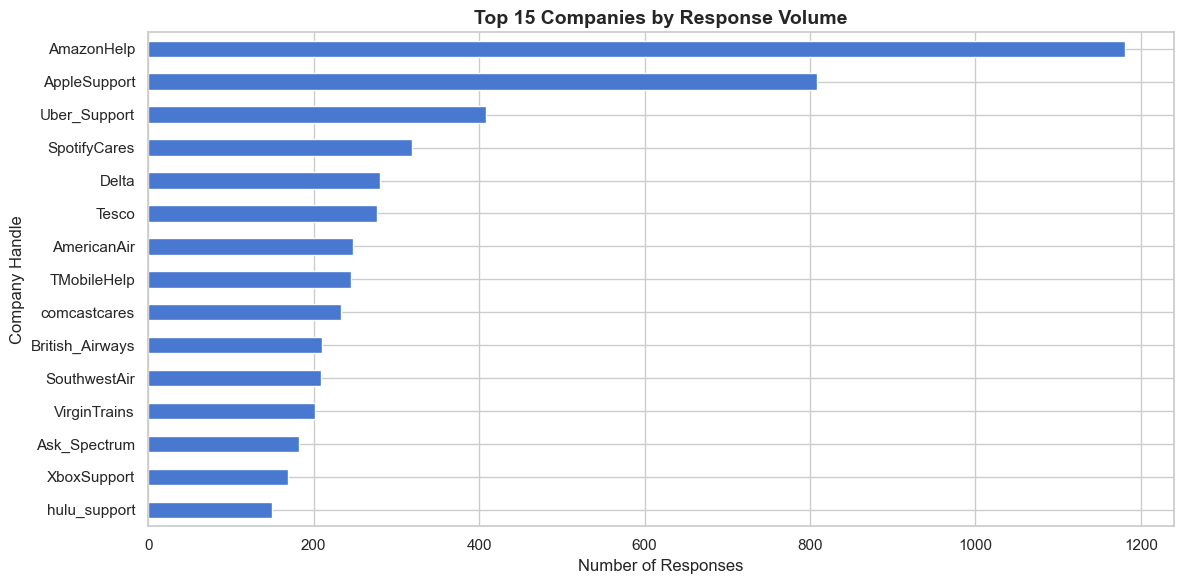

author_id
AmazonHelp         1181
AppleSupport        808
Uber_Support        408
SpotifyCares        319
Delta               280
Tesco               277
AmericanAir         248
TMobileHelp         245
comcastcares        233
British_Airways     210
SouthwestAir        209
VirginTrains        202
Ask_Spectrum        182
XboxSupport         169
hulu_support        149


In [5]:
# I created a new DataFrame containing only the outbound (company) tweets.
outbound = df[~df['inbound']].copy()

# I counted the number of responses made by each company and selected the top 15 companies.
top_companies = outbound['author_id'].value_counts().head(15)

# I created a figure and axis with a size of 12 inches by 6 inches.
fig, ax = plt.subplots(figsize=(12, 6))

# I plotted the top 15 companies as a horizontal bar chart using a muted color palette.
top_companies.plot(kind='barh', ax=ax, color=sns.color_palette('muted')[0])

# I added a title to the chart.
ax.set_title('Top 15 Companies by Response Volume', fontsize=14, fontweight='bold')

# I labeled the x-axis.
ax.set_xlabel('Number of Responses')

# I labeled the y-axis.
ax.set_ylabel('Company Handle')

# I inverted the y-axis so that the company with the highest response volume appeared at the top.
ax.invert_yaxis()

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the bar chart.
plt.show()

# I displayed the response counts of the top 15 companies in text format.
print(top_companies.to_string())

# First Response Time (FRT) Data Preparation and Calculation

In [6]:
# I created a DataFrame containing the inbound customer tweets with their tweet IDs and timestamps.
inbound_t = (
    df[df['inbound']]
    
    # I selected the required columns for the analysis.
    [['tweet_id', 'created_at']]
    
    # I renamed the columns to improve clarity.
    .rename(columns={'tweet_id': 'ref_id', 'created_at': 'customer_time'})
    
    # I removed rows containing missing values.
    .dropna()
)

# I converted the reference ID column into string format.
inbound_t['ref_id'] = inbound_t['ref_id'].astype(str)

# I created a DataFrame containing the outbound company responses.
outbound_t = (
    df[~df['inbound']]
    
    # I selected the required columns for response analysis.
    [['author_id', 'created_at', 'in_response_to_tweet_id']]
    
    # I renamed the selected columns for better understanding.
    .rename(columns={'author_id': 'company', 'created_at': 'response_time'})
    
    # I removed rows with missing response IDs or timestamps.
    .dropna(subset=['in_response_to_tweet_id', 'response_time'])
)

# I cleaned the response tweet ID by removing any decimal portion.
outbound_t['in_response_to_tweet_id'] = (
    outbound_t['in_response_to_tweet_id']
    
    # I converted the values into string format.
    .astype(str)
    
    # I split the values at the decimal point.
    .str.split('.')
    
    # I retained only the integer portion of the identifier.
    .str[0]
)

# I merged the customer tweets with the corresponding company responses.
frt_df = inbound_t.merge(
    
    # I specified the outbound response DataFrame.
    outbound_t,
    
    # I matched the customer tweet ID with the company response reference.
    left_on='ref_id',
    
    # I matched the response reference ID.
    right_on='in_response_to_tweet_id',
    
    # I performed an inner join to keep only matched records.
    how='inner'
)

# I calculated the First Response Time (FRT) in minutes.
frt_df['frt_minutes'] = (
    
    # I calculated the time difference between the company response and customer tweet.
    frt_df['response_time'] - frt_df['customer_time']
    
    # I converted the time difference into total seconds.
).dt.total_seconds() / 60

# I retained only realistic response times between 0 and 1440 minutes (24 hours).
frt_df = frt_df[frt_df['frt_minutes'].between(0, 1440)]

# I displayed the total number of matched customer-company response pairs.
print(f'Matched response pairs: {len(frt_df):,}')

# I displayed the descriptive statistics of the First Response Time in minutes.
print(f'\nOverall FRT (minutes):\n{frt_df["frt_minutes"].describe().round(1)}')

Matched response pairs: 62

Overall FRT (minutes):
count     62.0
mean     120.5
std      224.0
min        0.8
25%        8.4
50%       24.1
75%      120.2
max      990.7
Name: frt_minutes, dtype: float64


# Median First Response Time (FRT) Analysis by Company

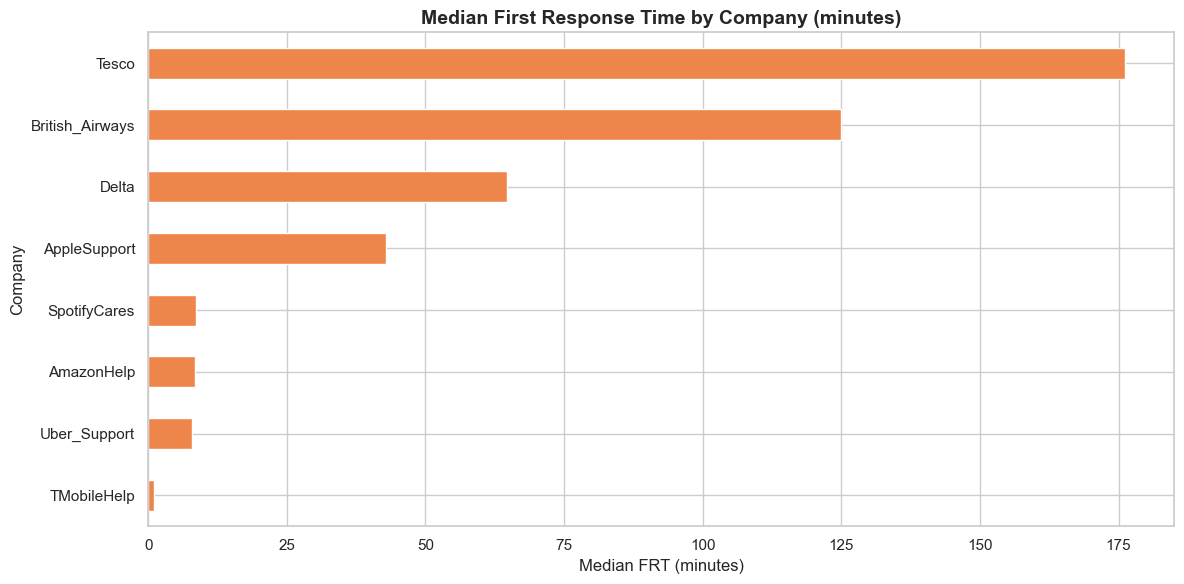

                 median    p75  count
company                              
TMobileHelp         1.1    2.1      3
Uber_Support        7.8   16.6      5
AmazonHelp          8.4   14.1      8
SpotifyCares        8.6    8.6      1
AppleSupport       42.9  253.1      8
Delta              64.7   80.4      4
British_Airways   124.9  124.9      1
Tesco             176.2  176.2      1


In [7]:
# I selected the top 10 companies based on their response volume.
top10 = top_companies.head(10).index.tolist()

# I filtered the First Response Time dataset to include only the top 10 companies.
frt_top = frt_df[frt_df['company'].isin(top10)]

# I calculated the First Response Time statistics for each company.
frt_summary = (
    
    # I grouped the data by company.
    frt_top.groupby('company')['frt_minutes']
    
    # I calculated the median, 75th percentile, and response count.
    .agg(
        median='median',
        p75=lambda x: x.quantile(0.75),
        count='count'
    )
    
    # I sorted the companies based on the median First Response Time.
    .sort_values('median')
)

# I created a figure and axis with a size of 12 inches by 6 inches.
fig, ax = plt.subplots(figsize=(12, 6))

# I plotted the median First Response Time of each company as a horizontal bar chart.
frt_summary['median'].plot(
    kind='barh',
    ax=ax,
    color=sns.color_palette('muted')[1]
)

# I added a title to the chart.
ax.set_title(
    'Median First Response Time by Company (minutes)',
    fontsize=14,
    fontweight='bold'
)

# I labeled the x-axis.
ax.set_xlabel('Median FRT (minutes)')

# I labeled the y-axis.
ax.set_ylabel('Company')

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the bar chart.
plt.show()

# I displayed the summary statistics rounded to one decimal place.
print(frt_summary.round(1).to_string())

# First Response Time (FRT) Distribution by Company

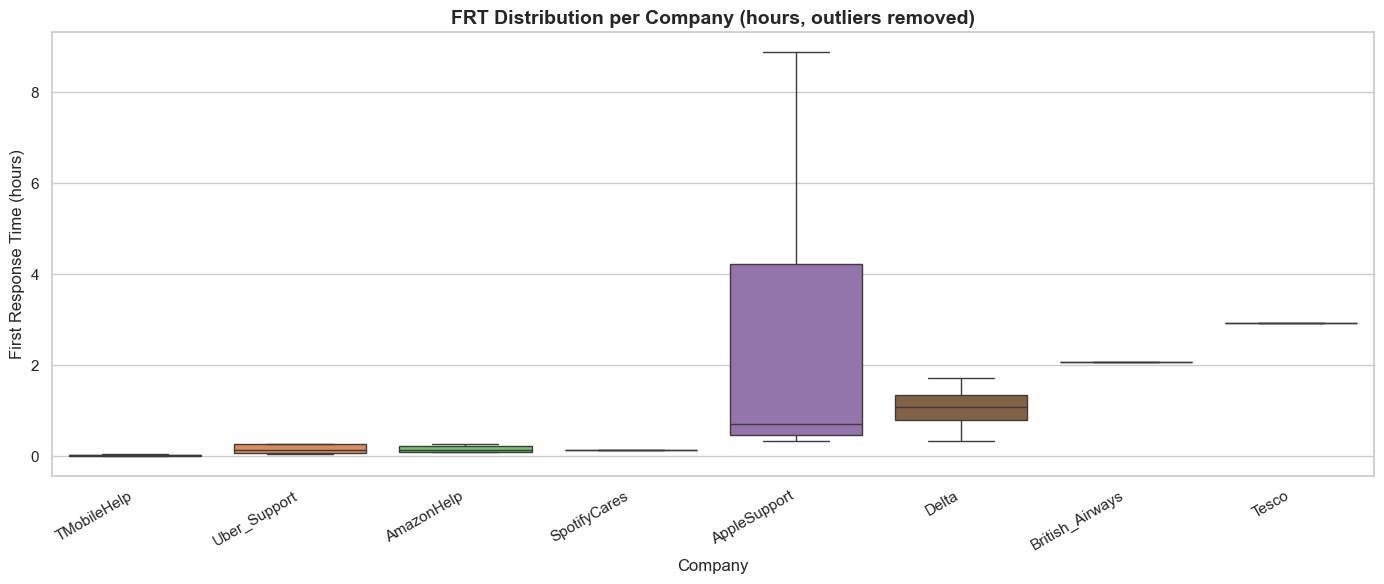

In [8]:
# I created a figure and axis with a size of 14 inches by 6 inches.
fig, ax = plt.subplots(figsize=(14, 6))

# I sorted the companies based on their median First Response Time.
order = frt_summary.sort_values('median').index.tolist()

# I filtered the First Response Time dataset to include only the selected companies.
frt_plot = frt_top[frt_top['company'].isin(order)].copy()

# I converted the First Response Time from minutes into hours.
frt_plot['frt_h'] = frt_plot['frt_minutes'] / 60

# I created a box plot to visualize the distribution of First Response Time for each company.
sns.boxplot(
    
    # I specified the dataset for plotting.
    data=frt_plot,
    
    # I selected the company column for the x-axis.
    x='company',
    
    # I selected the First Response Time in hours for the y-axis.
    y='frt_h',
    
    # I displayed the companies in ascending order of their median response time.
    order=order,
    
    # I applied a muted color palette to the box plot.
    palette='muted',
    
    # I removed the outliers from the visualization.
    showfliers=False,
    
    # I displayed the plot on the created axis.
    ax=ax
)

# I added a title to the box plot.
ax.set_title('FRT Distribution per Company (hours, outliers removed)', fontsize=14, fontweight='bold')

# I labeled the x-axis.
ax.set_xlabel('Company')

# I labeled the y-axis.
ax.set_ylabel('First Response Time (hours)')

# I rotated the company names to improve readability.
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the box plot.
plt.show()

# Tweet Volume Analysis by Hour of the Day

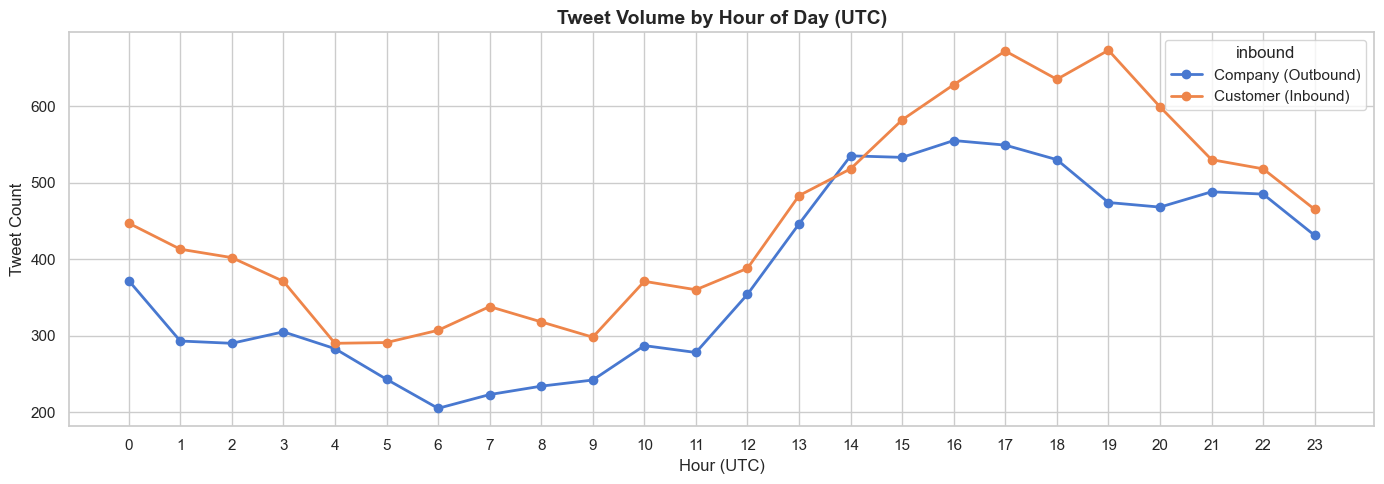

In [9]:
# I created a copy of the dataset after removing rows with missing timestamps.
df_time = df.dropna(subset=['created_at']).copy()

# I extracted the hour from the created_at column.
df_time['hour'] = df_time['created_at'].dt.hour

# I grouped the tweets by hour and inbound status to calculate the tweet count.
hourly = (
    df_time.groupby(['hour', 'inbound'])
    
    # I counted the number of tweets in each group.
    .size()
    
    # I converted the grouped results into a tabular format.
    .unstack(fill_value=0)
    
    # I renamed the columns for better readability.
    .rename(columns={True: 'Customer (Inbound)', False: 'Company (Outbound)'})
)

# I created a figure and axis with a size of 14 inches by 5 inches.
fig, ax = plt.subplots(figsize=(14, 5))

# I plotted the hourly tweet counts as a line chart.
hourly.plot(
    
    # I displayed the plot on the created axis.
    ax=ax,
    
    # I added circular markers to each data point.
    marker='o',
    
    # I set the line width to improve visibility.
    linewidth=2
)

# I added a title to the chart.
ax.set_title('Tweet Volume by Hour of Day (UTC)', fontsize=14, fontweight='bold')

# I labeled the x-axis.
ax.set_xlabel('Hour (UTC)')

# I labeled the y-axis.
ax.set_ylabel('Tweet Count')

# I displayed all 24 hourly intervals on the x-axis.
ax.set_xticks(range(24))

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the line chart.
plt.show()

# Tweet Length Distribution Analysis

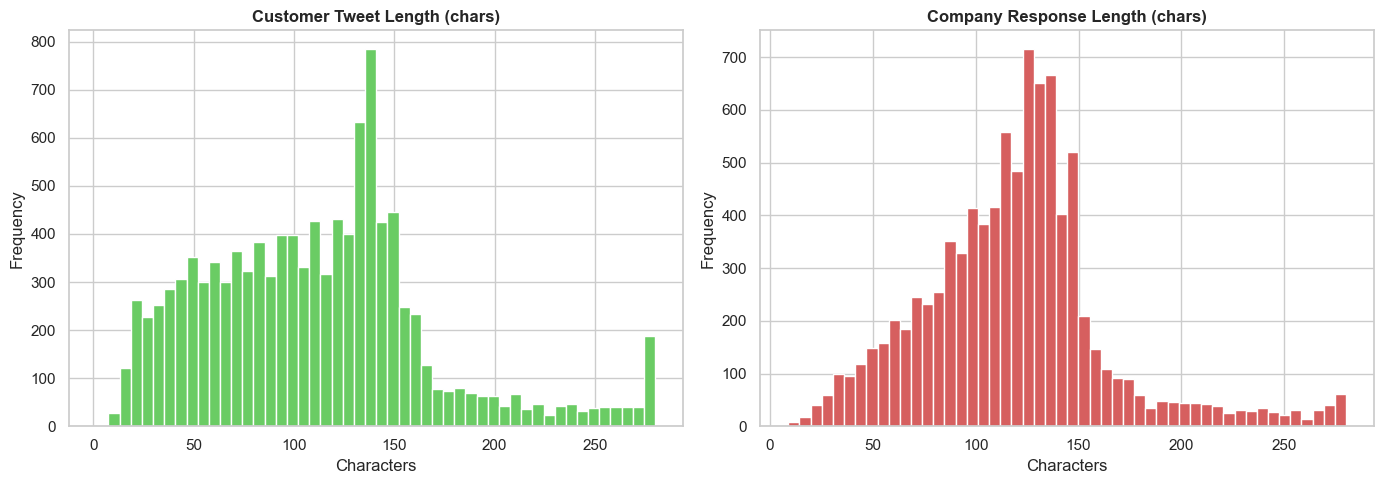

In [10]:
# I calculated the length of each tweet after replacing missing values with empty strings.
df['text_length'] = df['text'].fillna('').str.len()

# I created a figure with two subplots for comparing customer and company tweet lengths.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# I selected a muted color palette for the visualizations.
colors = sns.color_palette('muted')

# I plotted the distribution of customer tweet lengths.
df[df['inbound']]['text_length'].clip(upper=280).plot(
    
    # I selected a histogram for the visualization.
    kind='hist',
    
    # I divided the data into 50 bins.
    bins=50,
    
    # I displayed the histogram on the first subplot.
    ax=axes[0],
    
    # I applied a muted color to the bars.
    color=colors[2],
    
    # I added white borders to improve readability.
    edgecolor='white'
)

# I added a title to the customer tweet length histogram.
axes[0].set_title('Customer Tweet Length (chars)', fontsize=12, fontweight='bold')

# I labeled the x-axis of the first subplot.
axes[0].set_xlabel('Characters')

# I plotted the distribution of company response lengths.
df[~df['inbound']]['text_length'].clip(upper=280).plot(
    
    # I selected a histogram for the visualization.
    kind='hist',
    
    # I divided the data into 50 bins.
    bins=50,
    
    # I displayed the histogram on the second subplot.
    ax=axes[1],
    
    # I applied a muted color to the bars.
    color=colors[3],
    
    # I added white borders to improve readability.
    edgecolor='white'
)

# I added a title to the company response length histogram.
axes[1].set_title('Company Response Length (chars)', fontsize=12, fontweight='bold')

# I labeled the x-axis of the second subplot.
axes[1].set_xlabel('Characters')

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the histograms.
plt.show()

# Text Cleaning Function

In [11]:
# I defined a function to clean the textual data.
def clean_text(text):
    
    # I checked whether the input was a string.
    if not isinstance(text, str):
        
        # I returned an empty string if the input was not valid text.
        return ''
    
    # I removed all user mentions from the text.
    text = re.sub(r'@\w+', '', text)
    
    # I removed all website URLs from the text.
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # I removed all non-alphabetic characters from the text.
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # I removed extra spaces, trimmed whitespace, and converted the text to lowercase.
    text = re.sub(r'\s+', ' ', text).strip().lower()
    
    # I returned the cleaned text.
    return text

# Intent Labeling Based on Keyword Matching

In [12]:
# I created a list of keywords representing customer complaints.
COMPLAINT_KW = [
    'not working', 'broken', 'error', 'issue', 'problem', 'fail', 'failed',
    'terrible', 'awful', 'horrible', 'worst', 'disappointed', 'frustrated',
    'useless', 'wrong', 'bad', 'hate', 'ridiculous', 'unacceptable',
    'outraged', 'fix this', 'still not', 'never works', 'pathetic'
]

# I created a list of keywords representing positive customer feedback.
POSITIVE_KW = [
    'thank', 'thanks', 'great job', 'love this', 'awesome', 'excellent',
    'amazing', 'wonderful', 'fantastic', 'good job', 'well done',
    'appreciate', 'perfect'
]

# I defined a function to assign an intent label based on the tweet content.
def label_intent(text):
    
    # I checked whether the input was a valid non-empty string.
    if not isinstance(text, str) or len(text.strip()) == 0:
        
        # I returned the label "other" for invalid or empty text.
        return 'other'
    
    # I converted the text into lowercase for case-insensitive matching.
    t = text.lower()
    
    # I checked whether the text contained any complaint-related keywords.
    if any(kw in t for kw in COMPLAINT_KW):
        
        # I assigned the complaint label.
        return 'complaint'
    
    # I checked whether the text contained a question mark.
    if '?' in text:
        
        # I assigned the question label.
        return 'question'
    
    # I checked whether the text contained any positive keywords.
    if any(kw in t for kw in POSITIVE_KW):
        
        # I assigned the positive label.
        return 'positive'
    
    # I assigned the "other" label when no predefined intent was identified.
    return 'other'

# Customer Intent Classification and Summary

In [13]:
# I created a copy of the dataset containing only inbound customer tweets.
inbound_df = df[df['inbound']].copy()

# I cleaned the customer tweet text using the text cleaning function.
inbound_df['clean_text'] = inbound_df['text'].apply(clean_text)

# I assigned an intent label to each customer tweet.
inbound_df['intent'] = inbound_df['text'].apply(label_intent)

# I counted the number of tweets belonging to each intent category.
intent_counts = inbound_df['intent'].value_counts()

# I calculated the percentage distribution of each intent category.
intent_pct = inbound_df['intent'].value_counts(normalize=True).mul(100).round(1)

# I created a summary table containing the intent counts and percentages.
intent_summary = pd.DataFrame({
    
    # I added the count of each intent category.
    'count': intent_counts,
    
    # I added the percentage of each intent category.
    'pct': intent_pct
})

# I displayed the customer intent summary table.
print(intent_summary.to_string())

           count   pct
intent                
other       5920  54.3
question    2507  23.0
complaint   1652  15.2
positive     818   7.5


# Customer Tweet Intent Distribution Visualization

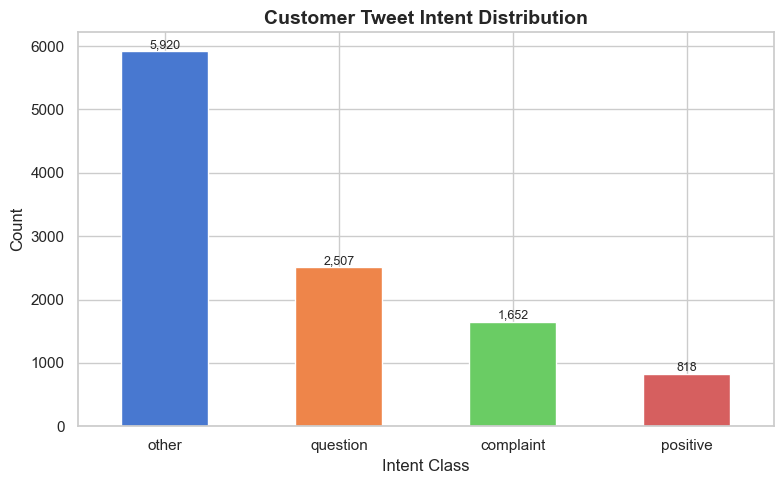

In [14]:
# I created a figure and axis with a size of 8 inches by 5 inches.
fig, ax = plt.subplots(figsize=(8, 5))

# I plotted the distribution of customer tweet intents as a bar chart.
intent_counts.plot(
    
    # I selected a bar chart for the visualization.
    kind='bar',
    
    # I displayed the chart on the created axis.
    ax=ax,
    
    # I applied the first four colors from the muted color palette.
    color=sns.color_palette('muted')[:4],
    
    # I added white borders to the bars.
    edgecolor='white'
)

# I added a title to the bar chart.
ax.set_title('Customer Tweet Intent Distribution', fontsize=14, fontweight='bold')

# I labeled the x-axis.
ax.set_xlabel('Intent Class')

# I labeled the y-axis.
ax.set_ylabel('Count')

# I displayed the intent labels horizontally.
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# I added the count value above each bar.
for p in ax.patches:
    
    # I annotated each bar with its corresponding count.
    ax.annotate(
        f'{int(p.get_height()):,}',
        
        # I positioned the annotation at the top center of each bar.
        (p.get_x() + p.get_width() / 2, p.get_height()),
        
        # I aligned the annotation horizontally at the center.
        ha='center',
        
        # I aligned the annotation just above the bar.
        va='bottom',
        
        # I set the annotation font size.
        fontsize=9
    )

# I adjusted the layout to prevent overlapping of chart elements.
plt.tight_layout()

# I displayed the bar chart.
plt.show()

# Balanced Dataset Preparation for Intent Classification

In [15]:
# I created a dataset containing the cleaned text and corresponding intent labels.
model_df = (
    inbound_df[['clean_text', 'intent']]
    
    # I removed rows containing missing values.
    .dropna()
    
    # I retained only the records with cleaned text longer than five characters.
    .loc[lambda x: x['clean_text'].str.len() > 5]
    
    # I reset the DataFrame index.
    .reset_index(drop=True)
)

# I determined the maximum number of samples to use from each intent category.
cap = min(model_df['intent'].value_counts().min(), 10000)

# I created a balanced dataset by sampling an equal number of records from each intent category.
model_sample = (
    model_df.groupby('intent', group_keys=False)
    
    # I randomly sampled records from each intent category.
    .apply(lambda x: x.sample(min(len(x), cap), random_state=42))
    
    # I reset the DataFrame index after sampling.
    .reset_index(drop=True)
)

# I displayed the total number of records in the balanced dataset.
print(f'Balanced sample: {len(model_sample):,} rows')

# I displayed the distribution of intent classes in the balanced dataset.
print(f'\nDistribution:\n{model_sample["intent"].value_counts()}')

Balanced sample: 3,272 rows

Distribution:
intent
complaint    818
other        818
positive     818
question     818
Name: count, dtype: int64


# Training and Testing Dataset Preparation

In [16]:
# I selected the cleaned text as the input feature.
X = model_sample['clean_text']

# I selected the intent labels as the target variable.
y = model_sample['intent']

# I divided the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    
    # I specified the input feature.
    X,
    
    # I specified the target variable.
    y,
    
    # I allocated 20% of the data for testing.
    test_size=0.2,
    
    # I set the random state to ensure reproducibility.
    random_state=42,
    
    # I maintained the class distribution in both training and testing datasets.
    stratify=y
)

# I displayed the number of records in the training and testing datasets.
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# I displayed the unique intent classes present in the dataset.
print(f'Classes: {sorted(y.unique())}')

Train: 2,617 | Test: 655
Classes: ['complaint', 'other', 'positive', 'question']


# Model Training and Evaluation 

# Baseline Models (Before Hyperparameter Tuning)

# Model 1 : Logistic Regression 

In [17]:
# I imported the Logistic Regression algorithm for text classification.
from sklearn.linear_model import LogisticRegression

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for Logistic Regression.
lr_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Logistic Regression classifier.
    ('clf', LogisticRegression(
        
        # I allowed a maximum of 1,000 iterations for model convergence.
        max_iter=1000,
        
        # I fixed the random state for reproducibility.
        random_state=42,
        
        # I enabled parallel processing using all available CPU cores.
        n_jobs=-1
    ))
])

# I trained the Logistic Regression model using the training dataset.
lr_pipeline.fit(X_train, y_train)

# I predicted the intent labels for the testing dataset.
y_pred_lr = lr_pipeline.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_lr = lr_pipeline.predict_proba(X_test)

# I calculated the classification accuracy.
bas_lr_accuracy = accuracy_score(y_test, y_pred_lr)

# I calculated the weighted precision score.
bas_lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the weighted recall score.
bas_lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the weighted F1-score.
bas_lr_f1_score = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the macro-average F1-score.
bas_lr_macro_f1_score = f1_score(
    y_test,
    y_pred_lr,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
bas_lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class='ovr',
    average='weighted'
)


# I displayed the model title.
print("Baseline Logistic Regression Performance")

# I displayed another separator line.


# I displayed the classification accuracy.
print(f"Accuracy        : {bas_lr_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {bas_lr_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {bas_lr_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {bas_lr_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {bas_lr_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {bas_lr_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")

# I displayed a separator line.


# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_lr))

Baseline Logistic Regression Performance
Accuracy        : 0.7344
Precision       : 0.7455
Recall          : 0.7344
F1-Score        : 0.7380
Macro F1-Score  : 0.7379
ROC-AUC         : 0.9119

Classification Report
              precision    recall  f1-score   support

   complaint       0.84      0.74      0.79       164
       other       0.60      0.70      0.64       163
    positive       0.93      0.88      0.91       164
    question       0.61      0.61      0.61       164

    accuracy                           0.73       655
   macro avg       0.75      0.73      0.74       655
weighted avg       0.75      0.73      0.74       655



# Model 2 : Random Forest 

In [18]:
# I imported the Random Forest Classifier for text classification.
from sklearn.ensemble import RandomForestClassifier

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the Random Forest classifier.
rf_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Random Forest classifier.
    ('clf', RandomForestClassifier(
        
        # I fixed the random state for reproducibility.
        random_state=42,
        
        # I enabled parallel processing using all available CPU cores.
        n_jobs=-1
    ))
])

# I trained the Random Forest model using the training dataset.
rf_pipeline.fit(X_train, y_train)

# I predicted the intent labels for the testing dataset.
y_pred_rf = rf_pipeline.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_rf = rf_pipeline.predict_proba(X_test)

# I calculated the classification accuracy.
bas_rf_accuracy = accuracy_score(y_test, y_pred_rf)

# I calculated the weighted precision score.
bas_rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the weighted recall score.
bas_rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the weighted F1-score.
bas_rf_f1_score = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the macro-average F1-score.
bas_rf_macro_f1_score = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
bas_rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)



# I displayed the model title.
print("Baseline Random Forest Performance")



# I displayed the classification accuracy.
print(f"Accuracy        : {bas_rf_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {bas_rf_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {bas_rf_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {bas_rf_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {bas_rf_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {bas_rf_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")


# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_rf))

Baseline Random Forest Performance
Accuracy        : 0.7603
Precision       : 0.7755
Recall          : 0.7603
F1-Score        : 0.7657
Macro F1-Score  : 0.7655
ROC-AUC         : 0.9189

Classification Report
              precision    recall  f1-score   support

   complaint       0.94      0.79      0.86       164
       other       0.62      0.69      0.65       163
    positive       0.96      0.93      0.94       164
    question       0.59      0.63      0.61       164

    accuracy                           0.76       655
   macro avg       0.78      0.76      0.77       655
weighted avg       0.78      0.76      0.77       655



# Model 3 : CatBoost 

In [20]:
# I imported the CatBoost Classifier for text classification.
from catboost import CatBoostClassifier

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the CatBoost classifier.
cb_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the CatBoost classifier.
    ('clf', CatBoostClassifier(
        
        # I fixed the random state for reproducibility.
        random_state=42,
        
        # I suppressed the training output.
        verbose=0
    ))
])

# I trained the CatBoost model using the training dataset.
cb_pipeline.fit(X_train, y_train)

# I predicted the intent labels for the testing dataset.
y_pred_cb = cb_pipeline.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_cb = cb_pipeline.predict_proba(X_test)

# I calculated the classification accuracy.
bas_cb_accuracy = accuracy_score(y_test, y_pred_cb)

# I calculated the weighted precision score.
bas_cb_precision = precision_score(
    y_test,
    y_pred_cb,
    average='weighted'
)

# I calculated the weighted recall score.
bas_cb_recall = recall_score(
    y_test,
    y_pred_cb,
    average='weighted'
)

# I calculated the weighted F1-score.
bas_cb_f1_score = f1_score(
    y_test,
    y_pred_cb,
    average='weighted'
)

# I calculated the macro-average F1-score.
bas_cb_macro_f1_score = f1_score(
    y_test,
    y_pred_cb,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
bas_cb_roc_auc = roc_auc_score(
    y_test,
    y_prob_cb,
    multi_class='ovr',
    average='weighted'
)


# I displayed the model title.
print("Baseline CatBoost Performance")

# I displayed the classification accuracy.
print(f"Accuracy        : {bas_cb_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {bas_cb_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {bas_cb_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {bas_cb_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {bas_cb_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {bas_cb_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")



# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_cb))

Baseline CatBoost Performance
Accuracy        : 0.7817
Precision       : 0.7949
Recall          : 0.7817
F1-Score        : 0.7852
Macro F1-Score  : 0.7850
ROC-AUC         : 0.9324

Classification Report
              precision    recall  f1-score   support

   complaint       0.97      0.84      0.90       164
       other       0.62      0.76      0.68       163
    positive       0.94      0.92      0.93       164
    question       0.66      0.60      0.63       164

    accuracy                           0.78       655
   macro avg       0.79      0.78      0.79       655
weighted avg       0.79      0.78      0.79       655



# Model 4 : Multinominal Naive Bayes 

In [21]:
# I imported the Multinomial Naïve Bayes classifier for text classification.
from sklearn.naive_bayes import MultinomialNB

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the Multinomial Naïve Bayes classifier.
nb_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Multinomial Naïve Bayes classifier.
    ('clf', MultinomialNB())
])

# I trained the Multinomial Naïve Bayes model using the training dataset.
nb_pipeline.fit(X_train, y_train)

# I predicted the intent labels for the testing dataset.
y_pred_nb = nb_pipeline.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_nb = nb_pipeline.predict_proba(X_test)

# I calculated the classification accuracy.
bas_nb_accuracy = accuracy_score(y_test, y_pred_nb)

# I calculated the weighted precision score.
bas_nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the weighted recall score.
bas_nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the weighted F1-score.
bas_nb_f1_score = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the macro-average F1-score.
bas_nb_macro_f1_score = f1_score(
    y_test,
    y_pred_nb,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
bas_nb_roc_auc = roc_auc_score(
    y_test,
    y_prob_nb,
    multi_class='ovr',
    average='weighted'
)

# I displayed the model title.
print("Baseline Multinomial Naïve Bayes Performance")

# I displayed the classification accuracy.
print(f"Accuracy        : {bas_nb_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {bas_nb_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {bas_nb_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {bas_nb_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {bas_nb_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {bas_nb_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")

# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_nb))

Baseline Multinomial Naïve Bayes Performance
Accuracy        : 0.6687
Precision       : 0.6659
Recall          : 0.6687
F1-Score        : 0.6643
Macro F1-Score  : 0.6640
ROC-AUC         : 0.8688

Classification Report
              precision    recall  f1-score   support

   complaint       0.73      0.75      0.74       164
       other       0.56      0.44      0.49       163
    positive       0.82      0.85      0.83       164
    question       0.55      0.64      0.59       164

    accuracy                           0.67       655
   macro avg       0.67      0.67      0.66       655
weighted avg       0.67      0.67      0.66       655



# Combined Comparative Table for all Baseline Models 

In [26]:
import pandas as pd

# I created a comparative results table for all baseline machine learning models.
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        bas_rf_accuracy,
        bas_cb_accuracy,
        bas_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        bas_rf_precision,
        bas_cb_precision,
        bas_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        bas_rf_recall,
        bas_cb_recall,
        bas_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        bas_rf_f1_score,
        bas_cb_f1_score,
        bas_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        bas_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        bas_rf_roc_auc,
        bas_cb_roc_auc,
        bas_nb_roc_auc
    ]
})

# I rounded all numerical values to four decimal places.
baseline_results = baseline_results.round(4)

# I defined different colors for each model.
row_colors = {
    "Logistic Regression": "#E8F4FD",
    "Random Forest": "#E8F8F0",
    "CatBoost": "#FFF4E5",
    "Multinomial Naïve Bayes": "#F4ECF7"
}

# I applied row-wise colors.
def highlight_rows(row):
    color = row_colors.get(row["Model"], "#FFFFFF")
    return [f"background-color: {color}"] * len(row)

# I displayed the styled comparative table.
baseline_results.style\
    .apply(highlight_rows, axis=1)\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Macro F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })\
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black",
        "font-size": "11pt"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#0B4F6C"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        }
    ])\
    .set_caption("Comparative Performance of Baseline Machine Learning Models")

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score,ROC-AUC
0,Logistic Regression,0.7344,0.7455,0.7344,0.7380,0.7379,0.9119
1,Random Forest,0.7603,0.7755,0.7603,0.7657,0.7655,0.9189
2,CatBoost,0.7817,0.7949,0.7817,0.7852,0.7850,0.9324
3,Multinomial Naïve Bayes,0.6687,0.6659,0.6687,0.6643,0.6640,0.8688


# Graphs for Each Metric for all Baseline Models 

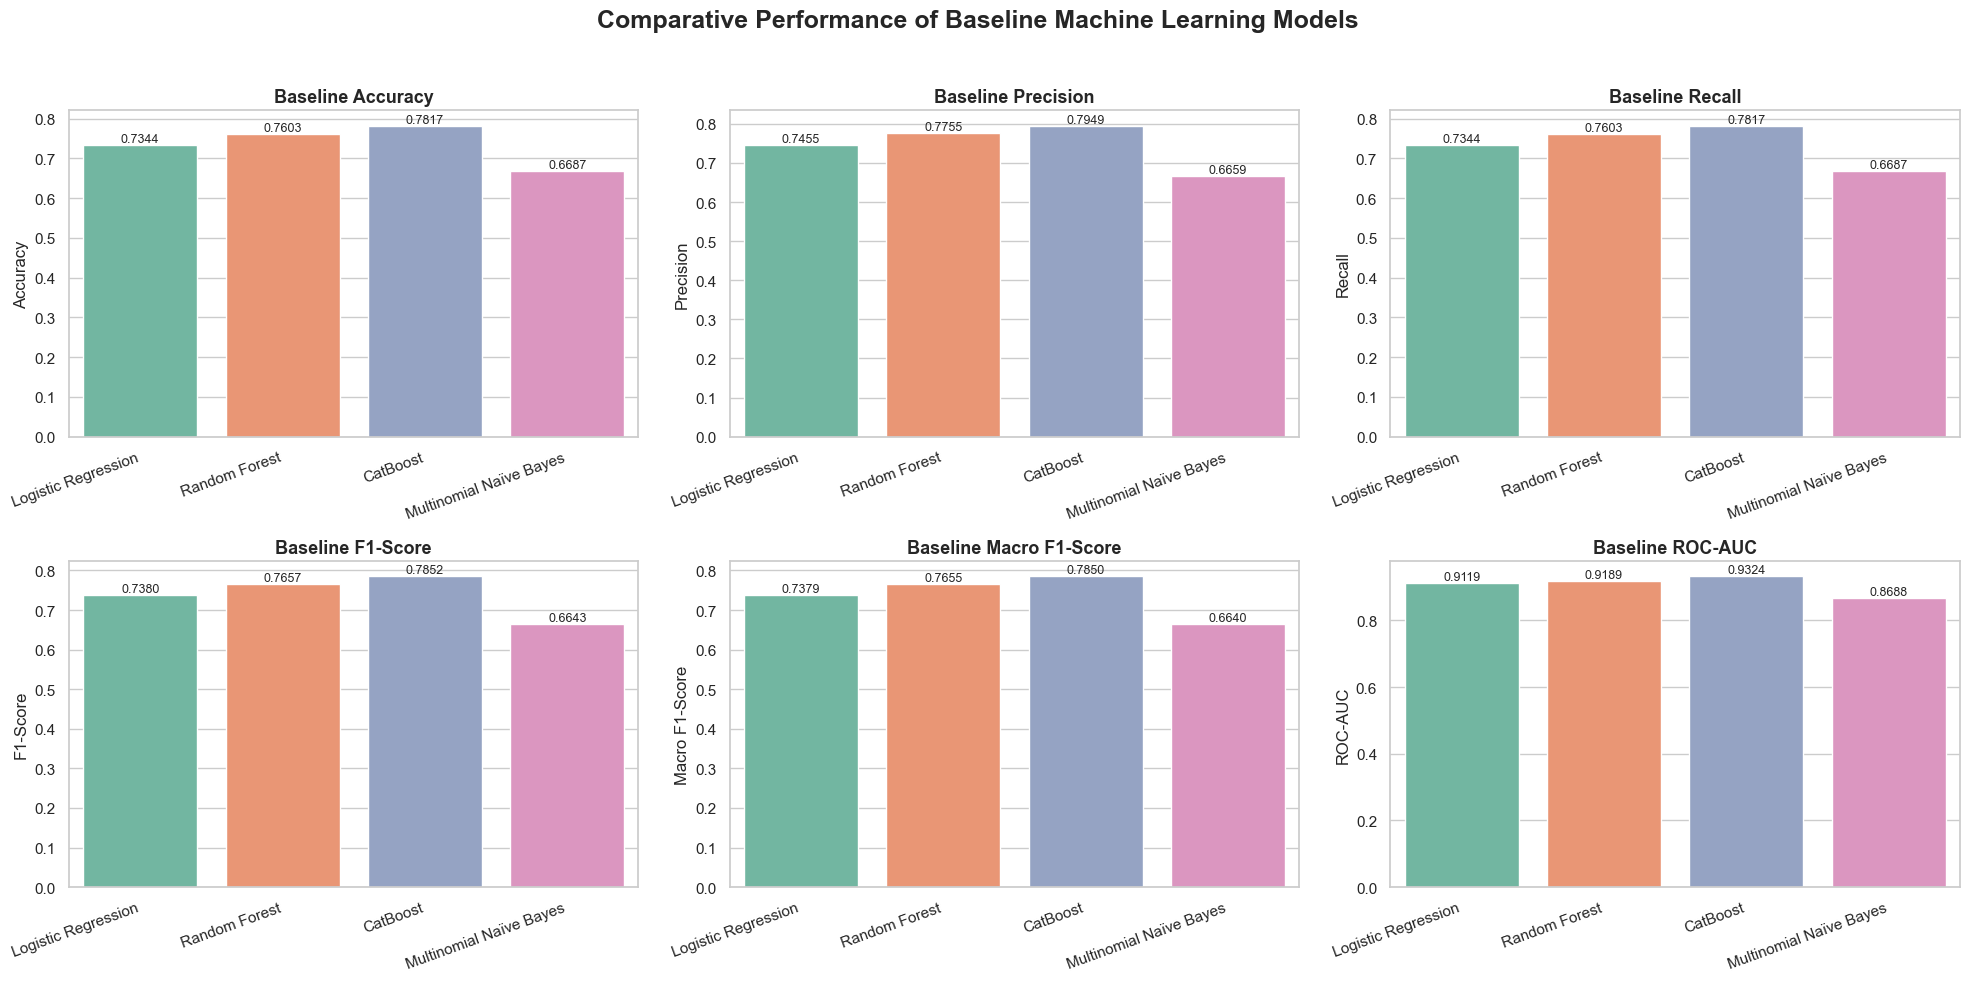

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        bas_rf_accuracy,
        bas_cb_accuracy,
        bas_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        bas_rf_precision,
        bas_cb_precision,
        bas_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        bas_rf_recall,
        bas_cb_recall,
        bas_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        bas_rf_f1_score,
        bas_cb_f1_score,
        bas_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        bas_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        bas_rf_roc_auc,
        bas_cb_roc_auc,
        bas_nb_roc_auc
    ]
})

# Plot settings
sns.set_theme(style="whitegrid")
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Macro F1-Score",
    "ROC-AUC"
]

colors = sns.color_palette("Set2", len(baseline_results))

# Create 2 × 3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# Plot each evaluation metric
for i, metric in enumerate(metrics):

    sns.barplot(
        data=baseline_results,
        x="Model",
        y=metric,
        palette=colors,
        ax=axes[i]
    )

    axes[i].set_title(f"Baseline {metric}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)

    axes[i].set_xticklabels(
        axes[i].get_xticklabels(),
        rotation=20,
        ha="right"
    )

    # Display values above each bar
    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.4f}",
            (
                p.get_x() + p.get_width()/2,
                p.get_height()
            ),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle(
    "Comparative Performance of Baseline Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Combined Comparative Bar Graph for all Baseline Models 

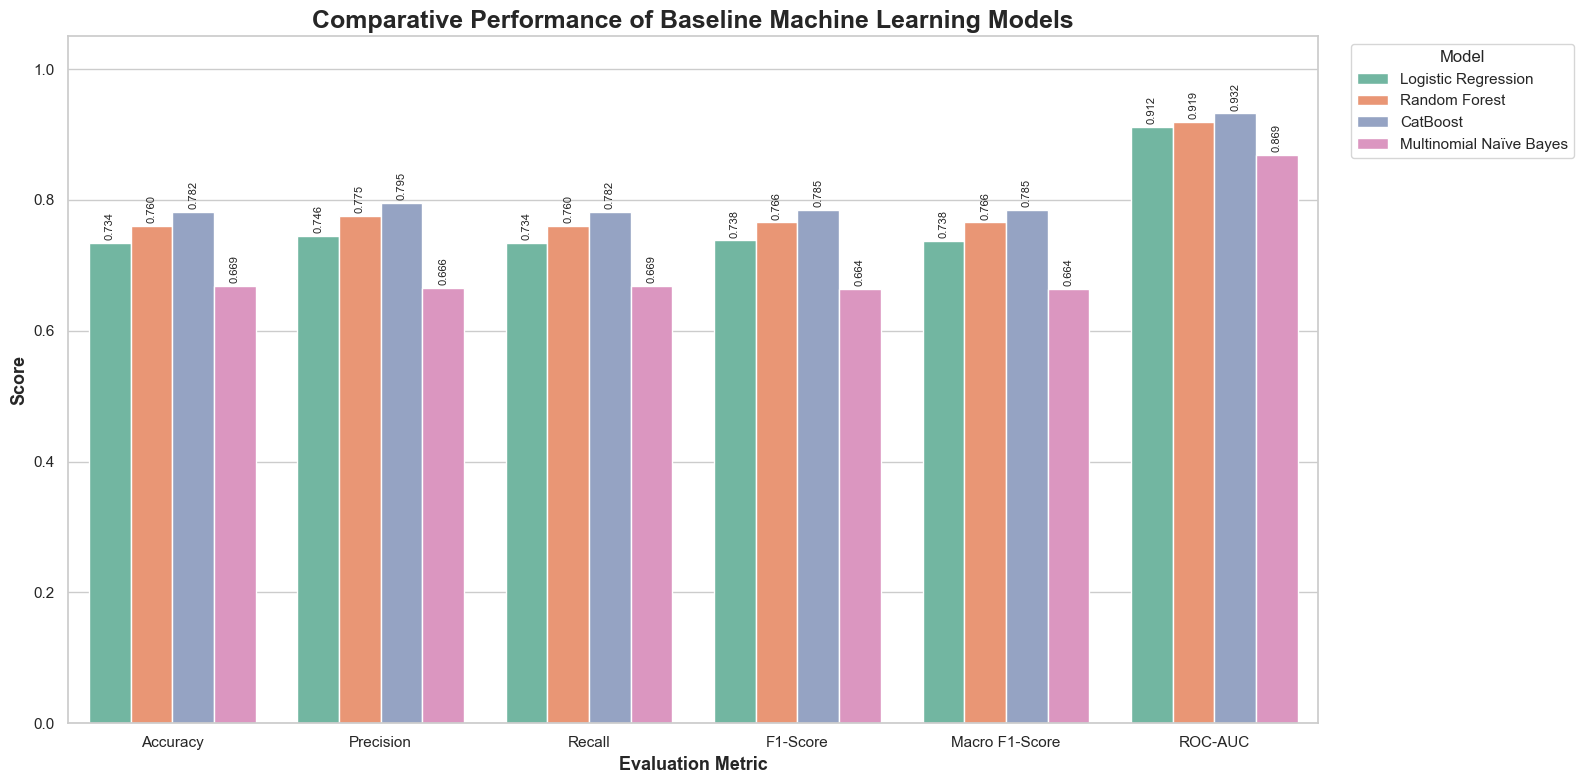

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        bas_rf_accuracy,
        bas_cb_accuracy,
        bas_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        bas_rf_precision,
        bas_cb_precision,
        bas_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        bas_rf_recall,
        bas_cb_recall,
        bas_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        bas_rf_f1_score,
        bas_cb_f1_score,
        bas_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        bas_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        bas_rf_roc_auc,
        bas_cb_roc_auc,
        bas_nb_roc_auc
    ]
})

# Convert the data into long format
plot_df = baseline_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=2,
        rotation=90
    )

plt.title(
    "Comparative Performance of Baseline Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric", fontsize=13, fontweight="bold")
plt.ylabel("Score", fontsize=13, fontweight="bold")
plt.ylim(0, 1.05)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

# Combined Comparative Macro F1-Score Bar Graph for all Baseline Models

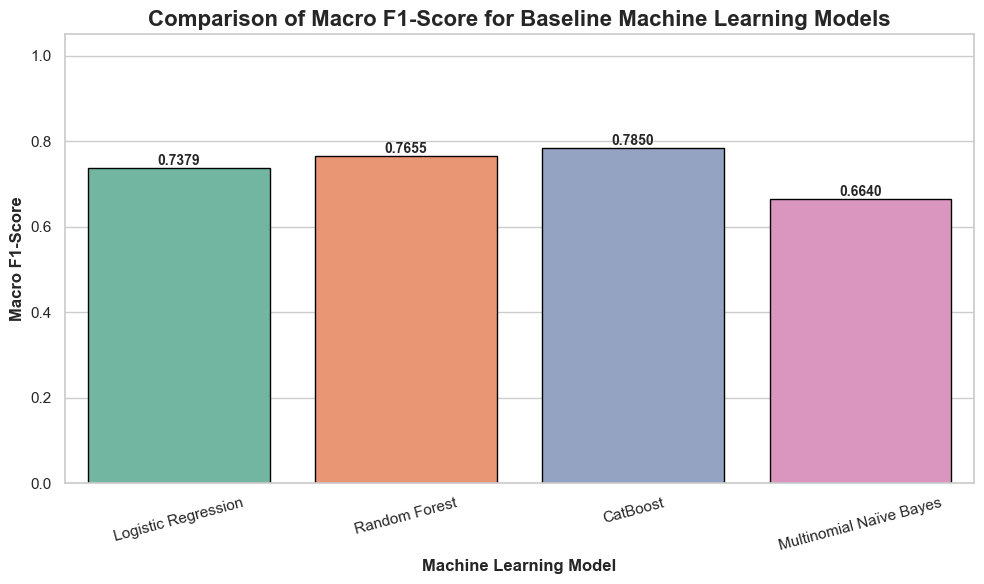

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
macro_f1_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        bas_nb_macro_f1_score
    ]
})

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=macro_f1_df,
    x="Model",
    y="Macro F1-Score",
    palette="Set2",
    edgecolor="black"
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Comparison of Macro F1-Score for Baseline Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model", fontsize=12, fontweight="bold")
plt.ylabel("Macro F1-Score", fontsize=12, fontweight="bold")

plt.ylim(0, 1.05)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Combined Comparative AUC-ROC  for all Baseline Models

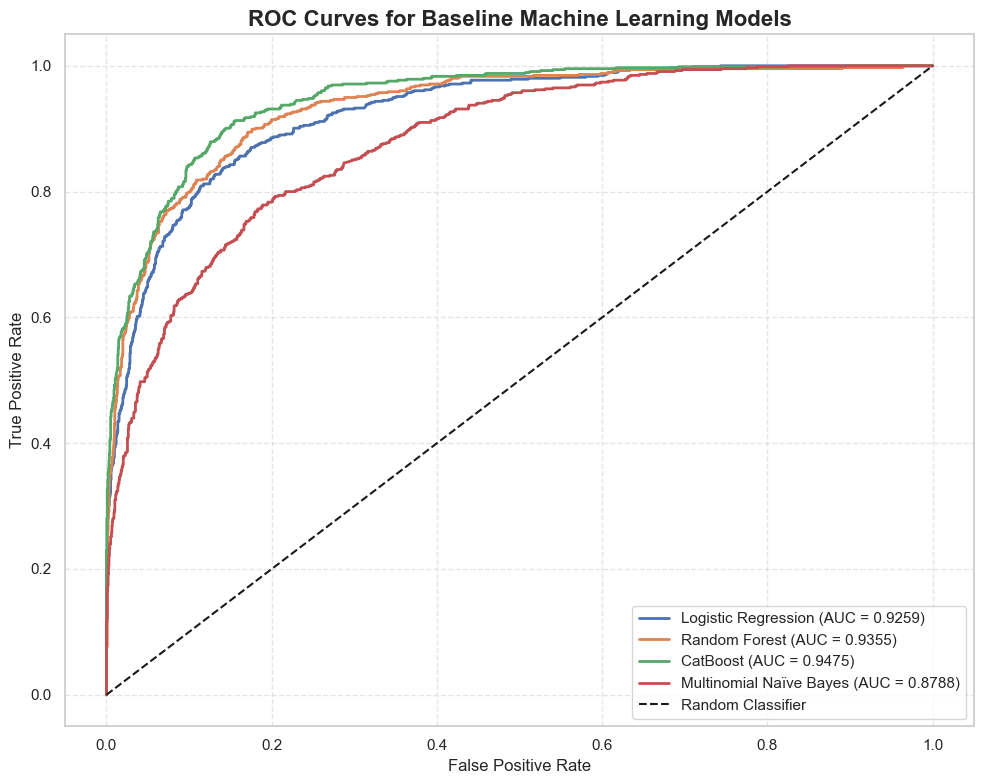

In [30]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the test labels
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_lr.ravel()
)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_rf.ravel()
)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# CatBoost
fpr_cb, tpr_cb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_cb.ravel()
)
roc_auc_cb = auc(fpr_cb, tpr_cb)

# Multinomial Naïve Bayes
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_nb.ravel()
)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Plot ROC Curves
plt.figure(figsize=(10,8))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_rf:.4f})'
)

plt.plot(
    fpr_cb,
    tpr_cb,
    linewidth=2,
    label=f'CatBoost (AUC = {roc_auc_cb:.4f})'
)

plt.plot(
    fpr_nb,
    tpr_nb,
    linewidth=2,
    label=f'Multinomial Naïve Bayes (AUC = {roc_auc_nb:.4f})'
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    'k--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.title(
    "ROC Curves for Baseline Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Hyperparameter Tuning 

# Model 1 : Tuned Logistic Regression 

In [22]:
# I imported the Logistic Regression algorithm for text classification.
from sklearn.linear_model import LogisticRegression

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the Randomized Search Cross-Validation method for hyperparameter optimization.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for Logistic Regression.
lr_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Logistic Regression classifier.
    ('clf', LogisticRegression(
        
        # I allowed a maximum of 1,000 iterations for convergence.
        max_iter=1000,
        
        # I fixed the random state for reproducibility.
        random_state=42
    ))
])

# I defined the hyperparameter search space for optimization.
param_dist = {
    
    # I specified the regularization strength values.
    'clf__C': [0.1, 1, 10],
    
    # I specified the optimization algorithms.
    'clf__solver': ['lbfgs', 'liblinear'],
    
    # I specified the class weighting options.
    'clf__class_weight': [None, 'balanced']
}

# I configured the Randomized Search Cross-Validation process.
random_lr = RandomizedSearchCV(
    
    # I specified the machine learning pipeline.
    estimator=lr_pipeline,
    
    # I provided the hyperparameter search space.
    param_distributions=param_dist,
    
    # I evaluated six randomly selected parameter combinations.
    n_iter=6,
    
    # I performed five-fold cross-validation.
    cv=5,
    
    # I optimized the weighted F1-score.
    scoring='f1_weighted',
    
    # I fixed the random state for reproducibility.
    random_state=42,
    
    # I enabled parallel processing using all available CPU cores.
    n_jobs=-1,
    
    # I displayed the optimization progress.
    verbose=1
)

# I trained the Randomized Search model using the training dataset.
random_lr.fit(X_train, y_train)

# I stored the best-performing optimized model.
best_lr = random_lr.best_estimator_

# I predicted the intent labels for the testing dataset.
y_pred_lr = best_lr.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_lr = best_lr.predict_proba(X_test)

# I calculated the classification accuracy.
tun_lr_accuracy = accuracy_score(y_test, y_pred_lr)

# I calculated the weighted precision score.
tun_lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the weighted recall score.
tun_lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the weighted F1-score.
tun_lr_f1_score = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

# I calculated the macro-average F1-score.
tun_lr_macro_f1_score = f1_score(
    y_test,
    y_pred_lr,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
tun_lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class='ovr',
    average='weighted'
)



# I displayed the model title.
print("Tuned Logistic Regression Performance")


# I displayed the best hyperparameter combination.
print("\nBest Parameters")
print(random_lr.best_params_)

# I displayed the best cross-validation score.
print(f"\nBest Cross Validation Score : {random_lr.best_score_:.4f}")

# I displayed the classification accuracy.
print(f"\nAccuracy        : {tun_lr_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {tun_lr_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {tun_lr_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {tun_lr_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {tun_lr_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {tun_lr_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")

# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_lr))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuned Logistic Regression Performance

Best Parameters
{'clf__solver': 'liblinear', 'clf__class_weight': None, 'clf__C': 10}

Best Cross Validation Score : 0.7383

Accuracy        : 0.7481
Precision       : 0.7526
Recall          : 0.7481
F1-Score        : 0.7500
Macro F1-Score  : 0.7498
ROC-AUC         : 0.9114

Classification Report
              precision    recall  f1-score   support

   complaint       0.87      0.82      0.84       164
       other       0.61      0.63      0.62       163
    positive       0.92      0.91      0.92       164
    question       0.61      0.63      0.62       164

    accuracy                           0.75       655
   macro avg       0.75      0.75      0.75       655
weighted avg       0.75      0.75      0.75       655



# Model 2 : Random Forest 

In [23]:
# I imported the Random Forest classifier for text classification.
from sklearn.ensemble import RandomForestClassifier

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the Randomized Search Cross-Validation method for hyperparameter optimization.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the Random Forest classifier.
rf_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Random Forest classifier.
    ('clf', RandomForestClassifier(
        
        # I fixed the random state for reproducibility.
        random_state=42,
        
        # I enabled parallel processing using all available CPU cores.
        n_jobs=-1
    ))
])

# I defined the hyperparameter search space for optimization.
param_dist = {
    
    # I specified the number of trees to be evaluated.
    'clf__n_estimators': [100, 200],
    
    # I specified the maximum tree depth values.
    'clf__max_depth': [10, None],
    
    # I specified the minimum number of samples required to split a node.
    'clf__min_samples_split': [2, 5]
}

# I configured the Randomized Search Cross-Validation process.
random_rf = RandomizedSearchCV(
    
    # I specified the machine learning pipeline.
    estimator=rf_pipeline,
    
    # I provided the hyperparameter search space.
    param_distributions=param_dist,
    
    # I evaluated six randomly selected parameter combinations.
    n_iter=6,
    
    # I performed five-fold cross-validation.
    cv=5,
    
    # I optimized the weighted F1-score.
    scoring='f1_weighted',
    
    # I fixed the random state for reproducibility.
    random_state=42,
    
    # I enabled parallel processing using all available CPU cores.
    n_jobs=-1,
    
    # I displayed the optimization progress.
    verbose=1
)

# I trained the Randomized Search model using the training dataset.
random_rf.fit(X_train, y_train)

# I stored the best-performing optimized model.
best_rf = random_rf.best_estimator_

# I predicted the intent labels for the testing dataset.
y_pred_rf = best_rf.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_rf = best_rf.predict_proba(X_test)

# I calculated the classification accuracy.
tun_rf_accuracy = accuracy_score(y_test, y_pred_rf)

# I calculated the weighted precision score.
tun_rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the weighted recall score.
tun_rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the weighted F1-score.
tun_rf_f1_score = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

# I calculated the macro-average F1-score.
tun_rf_macro_f1_score = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
tun_rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)



# I displayed the model title.
print("Tuned Random Forest Performance")



# I displayed the best hyperparameter combination.
print("\nBest Parameters")
print(random_rf.best_params_)

# I displayed the best cross-validation score.
print(f"\nBest Cross Validation Score : {random_rf.best_score_:.4f}")

# I displayed the classification accuracy.
print(f"\nAccuracy        : {tun_rf_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {tun_rf_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {tun_rf_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {tun_rf_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {tun_rf_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {tun_rf_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")

# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuned Random Forest Performance

Best Parameters
{'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__max_depth': None}

Best Cross Validation Score : 0.7623

Accuracy        : 0.7649
Precision       : 0.7819
Recall          : 0.7649
F1-Score        : 0.7707
Macro F1-Score  : 0.7706
ROC-AUC         : 0.9234

Classification Report
              precision    recall  f1-score   support

   complaint       0.94      0.79      0.86       164
       other       0.62      0.70      0.66       163
    positive       0.96      0.91      0.93       164
    question       0.61      0.66      0.63       164

    accuracy                           0.76       655
   macro avg       0.78      0.76      0.77       655
weighted avg       0.78      0.76      0.77       655



# Model 3 : Tuned CatBoost 

In [24]:
# I imported the CatBoost classifier for text classification.
from catboost import CatBoostClassifier

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the Randomized Search Cross-Validation method for hyperparameter optimization.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the CatBoost classifier.
cat_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the CatBoost classifier.
    ('clf', CatBoostClassifier(
        
        # I specified the multiclass loss function.
        loss_function='MultiClass',
        
        # I fixed the random state for reproducibility.
        random_state=42,
        
        # I suppressed the training output.
        verbose=0
    ))
])

# I defined the hyperparameter search space for optimization.
param_dist = {
    
    # I specified the number of boosting iterations.
    'clf__iterations': [100, 200],
    
    # I specified the tree depth values.
    'clf__depth': [4, 6],
    
    # I specified the learning rate values.
    'clf__learning_rate': [0.05, 0.1]
}

# I configured the Randomized Search Cross-Validation process.
random_cat = RandomizedSearchCV(
    
    # I specified the machine learning pipeline.
    estimator=cat_pipeline,
    
    # I provided the hyperparameter search space.
    param_distributions=param_dist,
    
    # I evaluated six randomly selected parameter combinations.
    n_iter=6,
    
    # I performed five-fold cross-validation.
    cv=5,
    
    # I optimized the weighted F1-score.
    scoring='f1_weighted',
    
    # I fixed the random state for reproducibility.
    random_state=42,
    
    # I enabled parallel processing using all available CPU cores.
    n_jobs=-1,
    
    # I displayed the optimization progress.
    verbose=1
)

# I trained the Randomized Search model using the training dataset.
random_cat.fit(X_train, y_train)

# I stored the best-performing optimized model.
best_cat = random_cat.best_estimator_

# I predicted the intent labels for the testing dataset.
y_pred_cat = best_cat.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_cat = best_cat.predict_proba(X_test)

# I calculated the classification accuracy.
tun_cat_accuracy = accuracy_score(y_test, y_pred_cat)

# I calculated the weighted precision score.
tun_cat_precision = precision_score(
    y_test,
    y_pred_cat,
    average='weighted'
)

# I calculated the weighted recall score.
tun_cat_recall = recall_score(
    y_test,
    y_pred_cat,
    average='weighted'
)

# I calculated the weighted F1-score.
tun_cat_f1_score = f1_score(
    y_test,
    y_pred_cat,
    average='weighted'
)

# I calculated the macro-average F1-score.
tun_cat_macro_f1_score = f1_score(
    y_test,
    y_pred_cat,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
tun_cat_roc_auc = roc_auc_score(
    y_test,
    y_prob_cat,
    multi_class='ovr',
    average='weighted'
)



# I displayed the model title.
print("Tuned CatBoost Performance")



# I displayed the best hyperparameter combination.
print("\nBest Parameters")
print(random_cat.best_params_)

# I displayed the best cross-validation score.
print(f"\nBest Cross Validation Score : {random_cat.best_score_:.4f}")

# I displayed the classification accuracy.
print(f"\nAccuracy        : {tun_cat_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {tun_cat_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {tun_cat_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {tun_cat_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {tun_cat_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {tun_cat_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")


# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_cat))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuned CatBoost Performance

Best Parameters
{'clf__learning_rate': 0.1, 'clf__iterations': 200, 'clf__depth': 6}

Best Cross Validation Score : 0.7793

Accuracy        : 0.7664
Precision       : 0.7814
Recall          : 0.7664
F1-Score        : 0.7696
Macro F1-Score  : 0.7695
ROC-AUC         : 0.9263

Classification Report
              precision    recall  f1-score   support

   complaint       0.96      0.82      0.89       164
       other       0.61      0.78      0.68       163
    positive       0.93      0.90      0.92       164
    question       0.63      0.56      0.59       164

    accuracy                           0.77       655
   macro avg       0.78      0.77      0.77       655
weighted avg       0.78      0.77      0.77       655



# Model 4 : Tuned Multinominal Naive Bayes 

In [31]:
# I imported the Multinomial Naïve Bayes classifier for text classification.
from sklearn.naive_bayes import MultinomialNB

# I imported the Pipeline class to combine preprocessing and model training.
from sklearn.pipeline import Pipeline

# I imported the TF-IDF Vectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I imported the Randomized Search Cross-Validation method for hyperparameter optimization.
from sklearn.model_selection import RandomizedSearchCV

# I imported the evaluation metrics to assess the classification model.
from sklearn.metrics import (
    
    # I imported the accuracy score to measure the overall prediction accuracy.
    accuracy_score,
    
    # I imported the precision score to evaluate the correctness of positive predictions.
    precision_score,
    
    # I imported the recall score to measure the proportion of correctly identified instances.
    recall_score,
    
    # I imported the F1-score to evaluate the balance between precision and recall.
    f1_score,
    
    # I imported the ROC-AUC score to evaluate the overall classification performance.
    roc_auc_score,
    
    # I imported the classification report to summarize the model performance.
    classification_report
)

# I created a machine learning pipeline for the Multinomial Naïve Bayes classifier.
nb_pipeline = Pipeline([
    
    # I configured the TF-IDF Vectorizer for feature extraction.
    ('tfidf', TfidfVectorizer(
        
        # I limited the vocabulary to the 5,000 most important features.
        max_features=5000,
        
        # I extracted only unigram features.
        ngram_range=(1, 1),
        
        # I ignored terms appearing in fewer than five documents.
        min_df=5,
        
        # I applied sublinear term frequency scaling.
        sublinear_tf=True
    )),
    
    # I configured the Multinomial Naïve Bayes classifier.
    ('clf', MultinomialNB())
])

# I defined the hyperparameter search space for optimization.
param_dist = {
    
    # I specified the smoothing parameter values.
    'clf__alpha': [0.1, 0.5, 1.0, 2.0]
}

# I configured the Randomized Search Cross-Validation process.
random_nb = RandomizedSearchCV(
    
    # I specified the machine learning pipeline.
    estimator=nb_pipeline,
    
    # I provided the hyperparameter search space.
    param_distributions=param_dist,
    
    # I evaluated four randomly selected parameter combinations.
    n_iter=4,
    
    # I performed five-fold cross-validation.
    cv=5,
    
    # I optimized the weighted F1-score.
    scoring='f1_weighted',
    
    # I fixed the random state for reproducibility.
    random_state=42,
    
    # I enabled parallel processing using all available CPU cores.
    n_jobs=-1,
    
    # I displayed the optimization progress.
    verbose=1
)

# I trained the Randomized Search model using the training dataset.
random_nb.fit(X_train, y_train)

# I stored the best-performing optimized model.
best_nb = random_nb.best_estimator_

# I predicted the intent labels for the testing dataset.
y_pred_nb = best_nb.predict(X_test)

# I predicted the class probabilities for ROC-AUC calculation.
y_prob_nb = best_nb.predict_proba(X_test)

# I calculated the classification accuracy.
tun_nb_accuracy = accuracy_score(y_test, y_pred_nb)

# I calculated the weighted precision score.
tun_nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the weighted recall score.
tun_nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the weighted F1-score.
tun_nb_f1_score = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

# I calculated the macro-average F1-score.
tun_nb_macro_f1_score = f1_score(
    y_test,
    y_pred_nb,
    average='macro'
)

# I calculated the weighted multi-class ROC-AUC score.
tun_nb_roc_auc = roc_auc_score(
    y_test,
    y_prob_nb,
    multi_class='ovr',
    average='weighted'
)
# I displayed the model title.
print("Tuned Multinomial Naïve Bayes Performance")

# I displayed the best hyperparameter combination.
print("\nBest Parameters")
print(random_nb.best_params_)

# I displayed the best cross-validation score.
print(f"\nBest Cross Validation Score : {random_nb.best_score_:.4f}")

# I displayed the classification accuracy.
print(f"\nAccuracy        : {tun_nb_accuracy:.4f}")

# I displayed the weighted precision.
print(f"Precision       : {tun_nb_precision:.4f}")

# I displayed the weighted recall.
print(f"Recall          : {tun_nb_recall:.4f}")

# I displayed the weighted F1-score.
print(f"F1-Score        : {tun_nb_f1_score:.4f}")

# I displayed the macro-average F1-score.
print(f"Macro F1-Score  : {tun_nb_macro_f1_score:.4f}")

# I displayed the weighted ROC-AUC score.
print(f"ROC-AUC         : {tun_nb_roc_auc:.4f}")

# I displayed a heading for the classification report.
print("\nClassification Report")

# I displayed the detailed classification report.
print(classification_report(y_test, y_pred_nb))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Tuned Multinomial Naïve Bayes Performance

Best Parameters
{'clf__alpha': 2.0}

Best Cross Validation Score : 0.6481

Accuracy        : 0.6733
Precision       : 0.6765
Recall          : 0.6733
F1-Score        : 0.6676
Macro F1-Score  : 0.6674
ROC-AUC         : 0.8757

Classification Report
              precision    recall  f1-score   support

   complaint       0.72      0.73      0.73       164
       other       0.62      0.42      0.50       163
    positive       0.82      0.84      0.83       164
    question       0.55      0.70      0.61       164

    accuracy                           0.67       655
   macro avg       0.68      0.67      0.67       655
weighted avg       0.68      0.67      0.67       655



# Combined Comparative Table for all Tuned Models 

In [32]:
import pandas as pd

# I created a comparative results table for all tuned machine learning models.
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        tun_lr_accuracy,
        tun_rf_accuracy,
        tun_cat_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        tun_lr_precision,
        tun_rf_precision,
        tun_cat_precision,
        tun_nb_precision
    ],
    "Recall": [
        tun_lr_recall,
        tun_rf_recall,
        tun_cat_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        tun_lr_f1_score,
        tun_rf_f1_score,
        tun_cat_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        tun_lr_macro_f1_score,
        tun_rf_macro_f1_score,
        tun_cat_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        tun_lr_roc_auc,
        tun_rf_roc_auc,
        tun_cat_roc_auc,
        tun_nb_roc_auc
    ]
})

# I rounded all numerical values to four decimal places.
tuned_results = tuned_results.round(4)

# I assigned a different background color to each model.
row_colors = {
    "Logistic Regression": "#E8F4FD",      # Light Blue
    "Random Forest": "#E8F8F0",            # Light Green
    "CatBoost": "#FFF4E5",                 # Light Orange
    "Multinomial Naïve Bayes": "#F4ECF7"   # Light Purple
}

# I created a function to apply row colors.
def highlight_rows(row):
    color = row_colors.get(row["Model"], "#FFFFFF")
    return [f"background-color: {color}"] * len(row)

# I displayed the styled comparative table.
tuned_results.style\
    .apply(highlight_rows, axis=1)\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Macro F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })\
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black",
        "font-size": "11pt"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#0B4F6C"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        }
    ])\
    .set_caption("Comparative Performance of Tuned Machine Learning Models")

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score,ROC-AUC
0,Logistic Regression,0.7481,0.7526,0.7481,0.7500,0.7498,0.9114
1,Random Forest,0.7649,0.7819,0.7649,0.7707,0.7706,0.9234
2,CatBoost,0.7664,0.7814,0.7664,0.7696,0.7695,0.9263
3,Multinomial Naïve Bayes,0.6733,0.6765,0.6733,0.6676,0.6674,0.8757


# Graphs for Each Metric for all Tuned Models

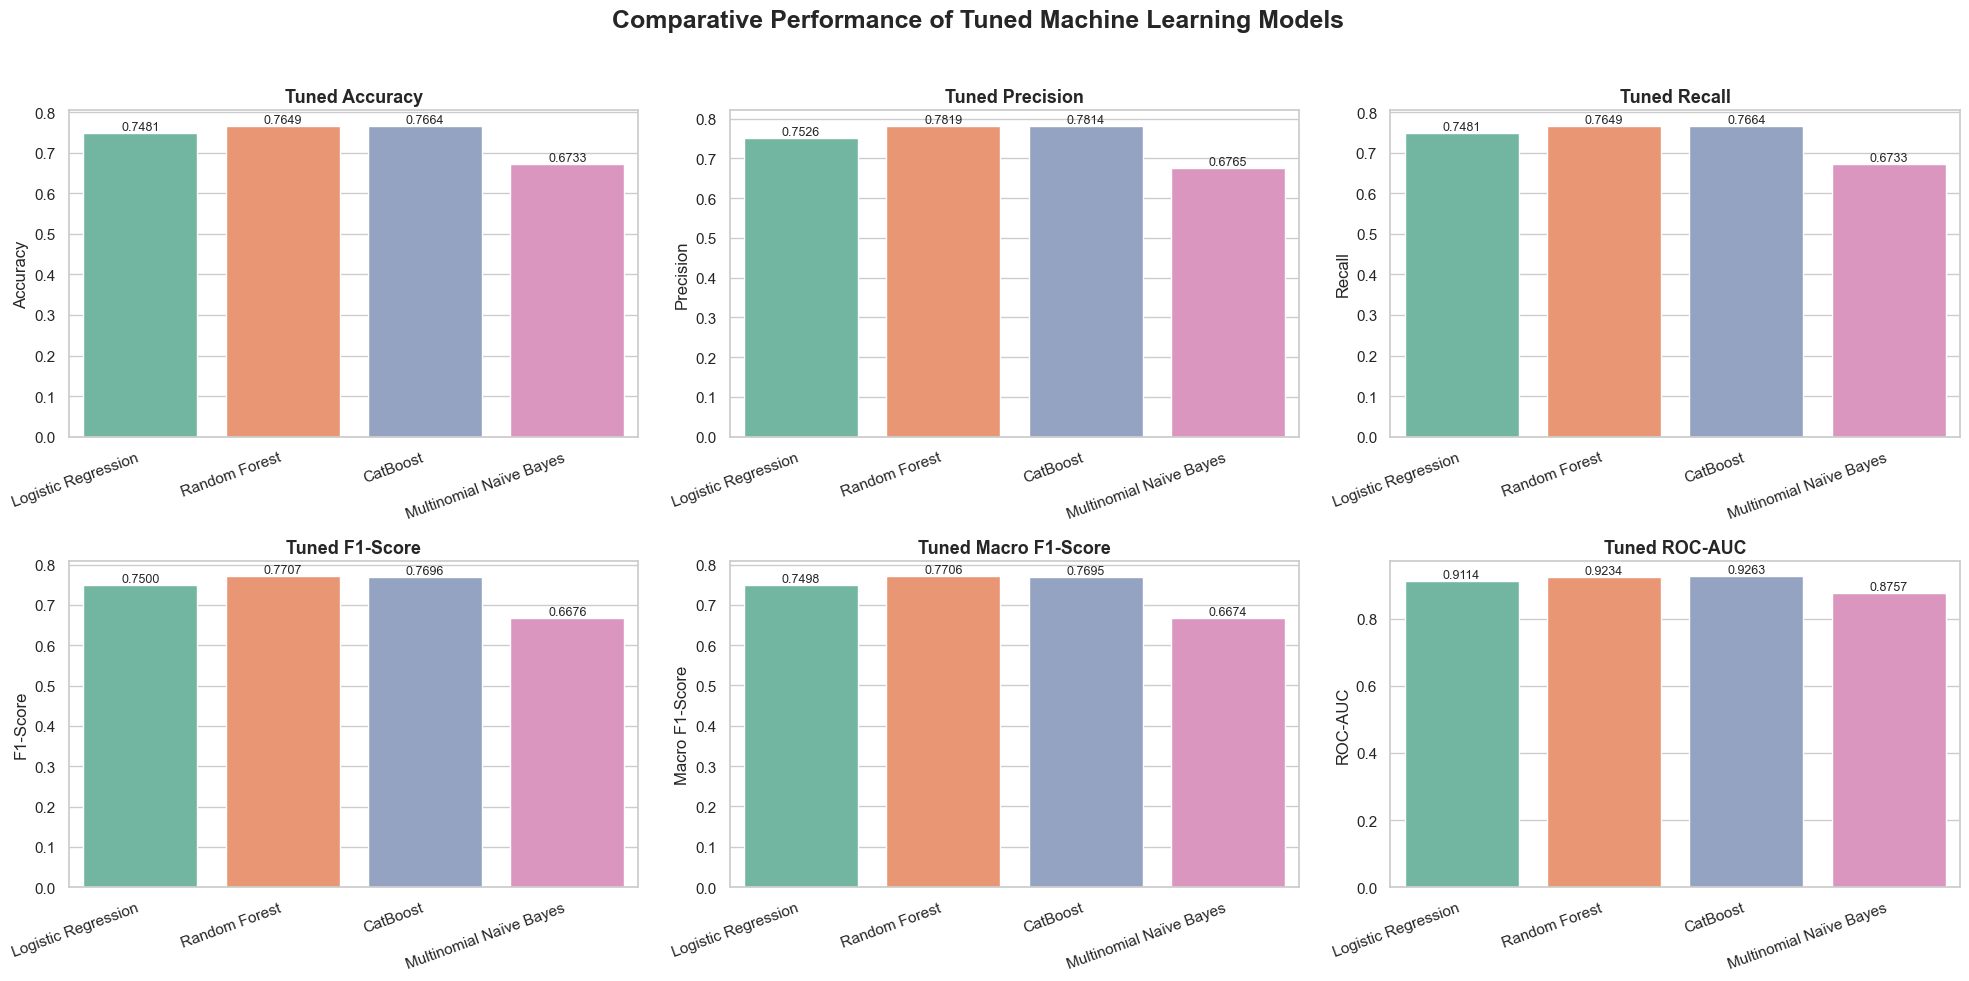

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        tun_lr_accuracy,
        tun_rf_accuracy,
        tun_cat_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        tun_lr_precision,
        tun_rf_precision,
        tun_cat_precision,
        tun_nb_precision
    ],
    "Recall": [
        tun_lr_recall,
        tun_rf_recall,
        tun_cat_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        tun_lr_f1_score,
        tun_rf_f1_score,
        tun_cat_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        tun_lr_macro_f1_score,
        tun_rf_macro_f1_score,
        tun_cat_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        tun_lr_roc_auc,
        tun_rf_roc_auc,
        tun_cat_roc_auc,
        tun_nb_roc_auc
    ]
})

# Plot settings
sns.set_theme(style="whitegrid")

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Macro F1-Score",
    "ROC-AUC"
]

colors = sns.color_palette("Set2", len(tuned_results))

# Create 2 × 3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# Plot each evaluation metric
for i, metric in enumerate(metrics):

    sns.barplot(
        data=tuned_results,
        x="Model",
        y=metric,
        palette=colors,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Tuned {metric}",
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)

    axes[i].set_xticklabels(
        axes[i].get_xticklabels(),
        rotation=20,
        ha="right"
    )

    # Display values above each bar
    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.4f}",
            (
                p.get_x() + p.get_width()/2,
                p.get_height()
            ),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle(
    "Comparative Performance of Tuned Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Combined Comparative Bar Graph for all Tuned Models

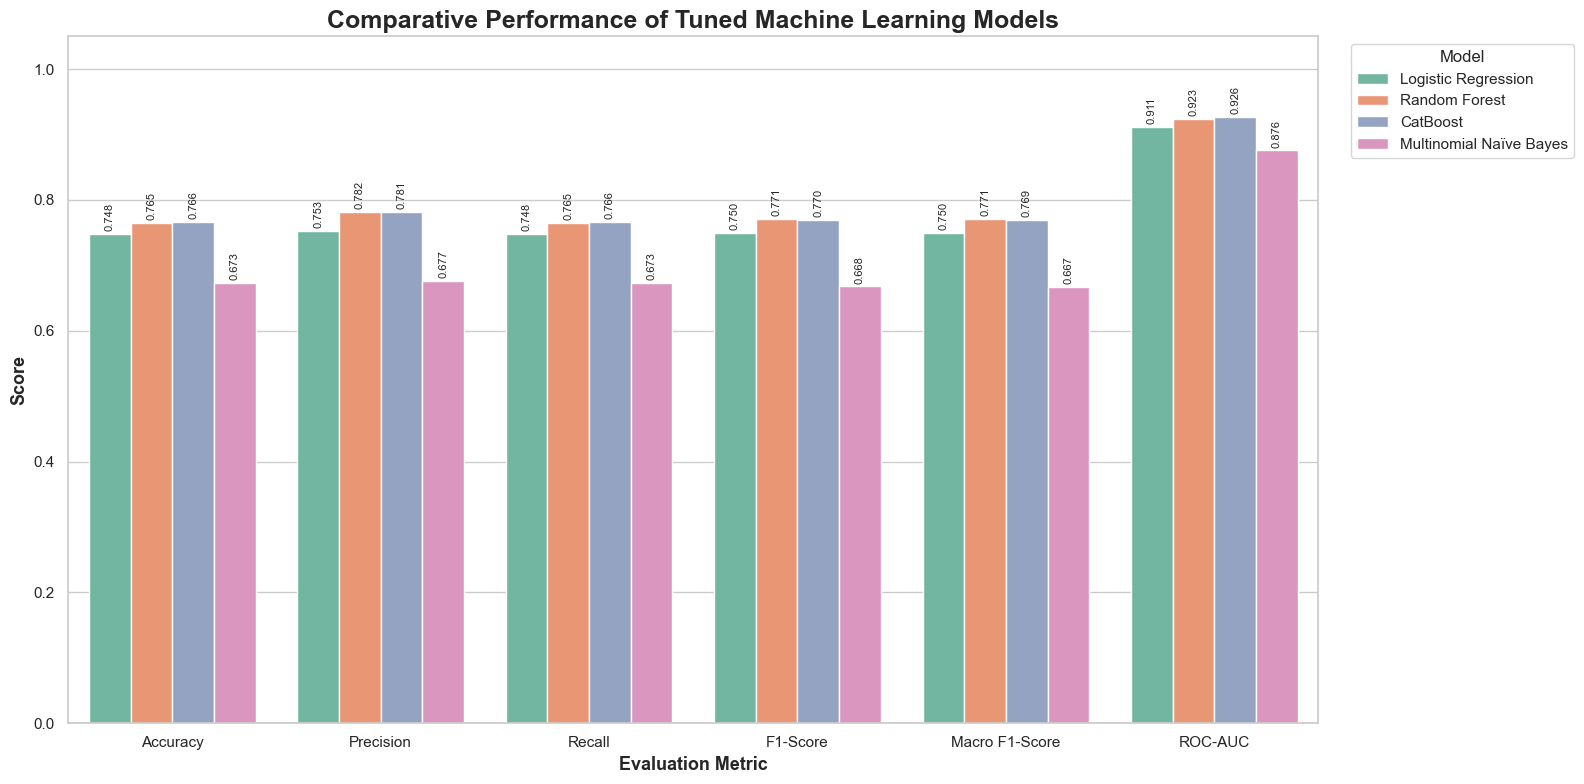

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Accuracy": [
        tun_lr_accuracy,
        tun_rf_accuracy,
        tun_cat_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        tun_lr_precision,
        tun_rf_precision,
        tun_cat_precision,
        tun_nb_precision
    ],
    "Recall": [
        tun_lr_recall,
        tun_rf_recall,
        tun_cat_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        tun_lr_f1_score,
        tun_rf_f1_score,
        tun_cat_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        tun_lr_macro_f1_score,
        tun_rf_macro_f1_score,
        tun_cat_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        tun_lr_roc_auc,
        tun_rf_roc_auc,
        tun_cat_roc_auc,
        tun_nb_roc_auc
    ]
})

# Convert the data into long format
plot_df = tuned_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=2,
        rotation=90
    )

plt.title(
    "Comparative Performance of Tuned Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metric",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

# Combined Comparative Macro F1-Score Bar Graph for all Tuned Models

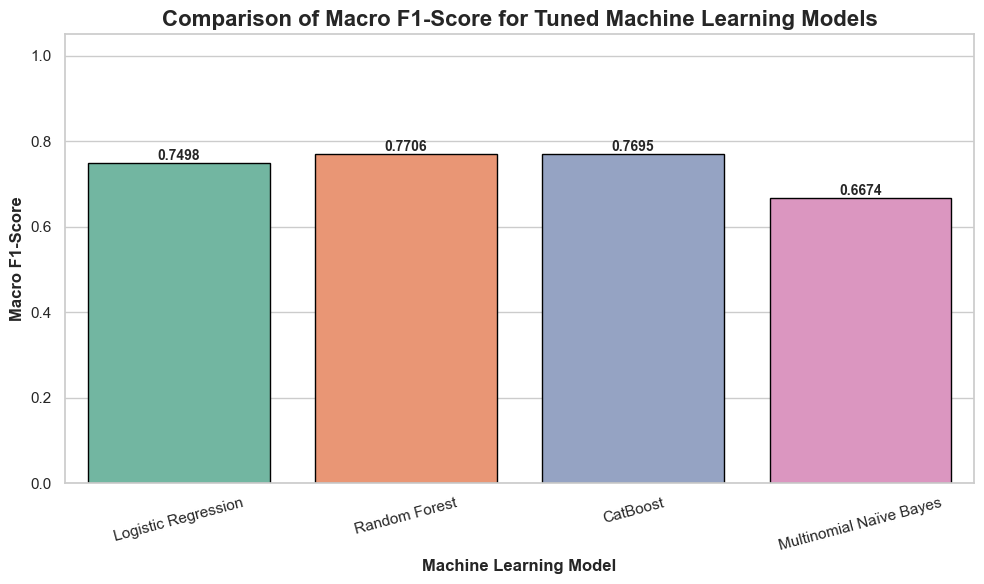

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
macro_f1_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "Multinomial Naïve Bayes"
    ],
    "Macro F1-Score": [
        tun_lr_macro_f1_score,
        tun_rf_macro_f1_score,
        tun_cat_macro_f1_score,
        tun_nb_macro_f1_score
    ]
})

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=macro_f1_df,
    x="Model",
    y="Macro F1-Score",
    palette="Set2",
    edgecolor="black"
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Comparison of Macro F1-Score for Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Macro F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 1.05)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Combined Comparative AUC-ROC  for all Tuned Models

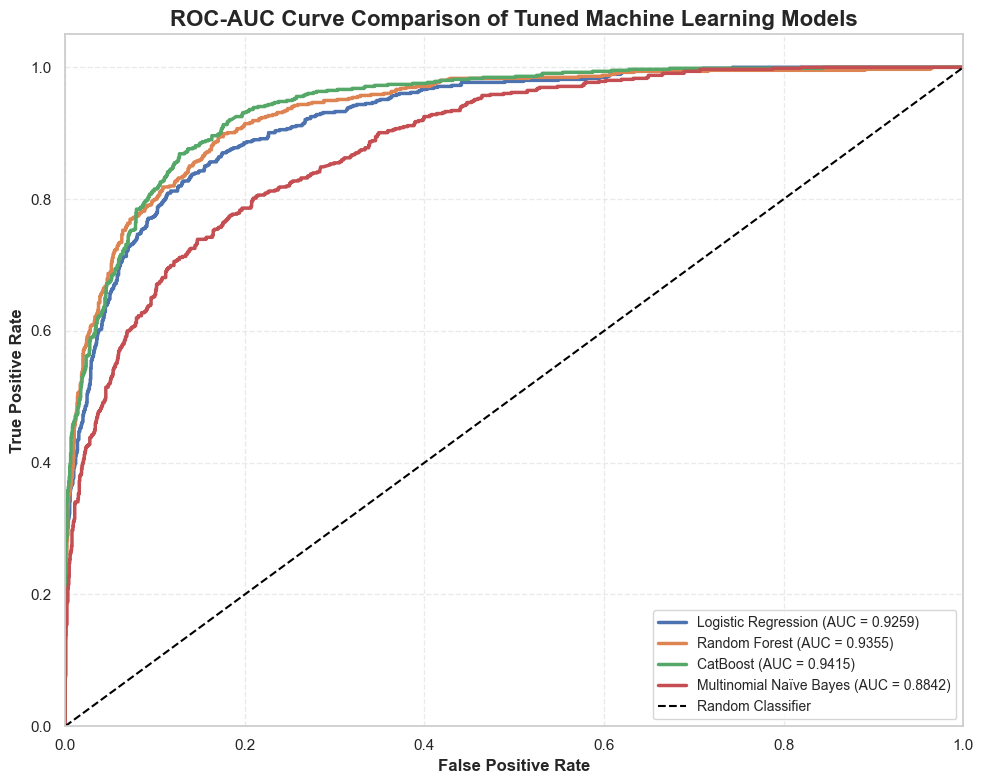

In [36]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert the multiclass labels into binary format
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_lr.ravel()
)
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_rf.ravel()
)
auc_rf = auc(fpr_rf, tpr_rf)

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_cat.ravel()
)
auc_cat = auc(fpr_cat, tpr_cat)

# Multinomial Naïve Bayes
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_nb.ravel()
)
auc_nb = auc(fpr_nb, tpr_nb)

# Plot ROC Curves
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2.5,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2.5,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

plt.plot(
    fpr_cat,
    tpr_cat,
    linewidth=2.5,
    label=f'CatBoost (AUC = {auc_cat:.4f})'
)

plt.plot(
    fpr_nb,
    tpr_nb,
    linewidth=2.5,
    label=f'Multinomial Naïve Bayes (AUC = {auc_nb:.4f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC-AUC Curve Comparison of Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

# Combined Comparative Table for all Baseline & Tuned Models

In [37]:
import pandas as pd

# Create comparison DataFrame
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Logistic Regression (Tuned)",
        "Random Forest (Baseline)",
        "Random Forest (Tuned)",
        "CatBoost (Baseline)",
        "CatBoost (Tuned)",
        "Multinomial Naïve Bayes (Baseline)",
        "Multinomial Naïve Bayes (Tuned)"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        tun_lr_accuracy,
        bas_rf_accuracy,
        tun_rf_accuracy,
        bas_cb_accuracy,
        tun_cat_accuracy,
        bas_nb_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        tun_lr_precision,
        bas_rf_precision,
        tun_rf_precision,
        bas_cb_precision,
        tun_cat_precision,
        bas_nb_precision,
        tun_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        tun_lr_recall,
        bas_rf_recall,
        tun_rf_recall,
        bas_cb_recall,
        tun_cat_recall,
        bas_nb_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        tun_lr_f1_score,
        bas_rf_f1_score,
        tun_rf_f1_score,
        bas_cb_f1_score,
        tun_cat_f1_score,
        bas_nb_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        tun_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        tun_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        tun_cat_macro_f1_score,
        bas_nb_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        tun_lr_roc_auc,
        bas_rf_roc_auc,
        tun_rf_roc_auc,
        bas_cb_roc_auc,
        tun_cat_roc_auc,
        bas_nb_roc_auc,
        tun_nb_roc_auc
    ]
})

# Round values
comparison_results = comparison_results.round(4)

# Row colors
row_colors = {
    "Logistic Regression (Baseline)": "#E8F4FD",
    "Logistic Regression (Tuned)": "#CFE2FF",

    "Random Forest (Baseline)": "#E8F8F0",
    "Random Forest (Tuned)": "#D5F5E3",

    "CatBoost (Baseline)": "#FFF4E5",
    "CatBoost (Tuned)": "#FDEBD0",

    "Multinomial Naïve Bayes (Baseline)": "#F4ECF7",
    "Multinomial Naïve Bayes (Tuned)": "#E8DAEF"
}

# Apply row colors
def highlight_rows(row):
    color = row_colors.get(row["Model"], "#FFFFFF")
    return [f"background-color: {color}"] * len(row)

# Display styled table
comparison_results.style\
    .apply(highlight_rows, axis=1)\
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Macro F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })\
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black",
        "font-size": "11pt"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#0B4F6C"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        }
    ])\
    .set_caption("Comparative Performance of Baseline and Tuned Machine Learning Models")

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7344,0.7455,0.7344,0.7380,0.7379,0.9119
1,Logistic Regression (Tuned),0.7481,0.7526,0.7481,0.7500,0.7498,0.9114
2,Random Forest (Baseline),0.7603,0.7755,0.7603,0.7657,0.7655,0.9189
3,Random Forest (Tuned),0.7649,0.7819,0.7649,0.7707,0.7706,0.9234
4,CatBoost (Baseline),0.7817,0.7949,0.7817,0.7852,0.7850,0.9324
5,CatBoost (Tuned),0.7664,0.7814,0.7664,0.7696,0.7695,0.9263
6,Multinomial Naïve Bayes (Baseline),0.6687,0.6659,0.6687,0.6643,0.6640,0.8688
7,Multinomial Naïve Bayes (Tuned),0.6733,0.6765,0.6733,0.6676,0.6674,0.8757


# Combined Comparative Bar Graph for all Baseline & Tuned Models

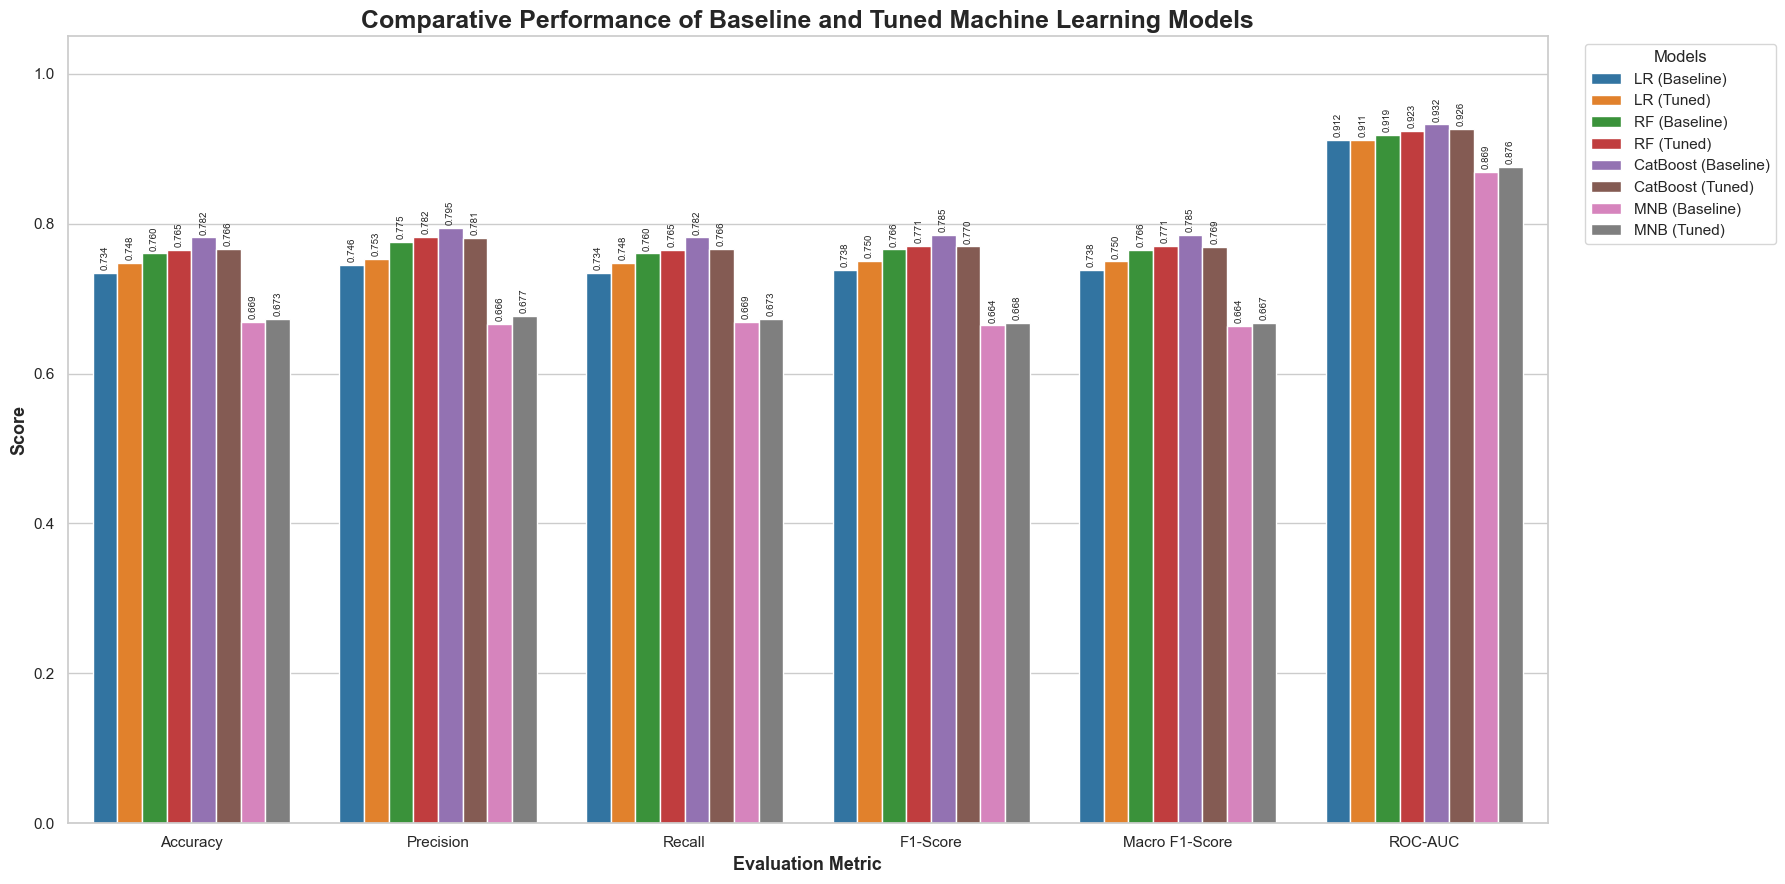

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison DataFrame
comparison_results = pd.DataFrame({
    "Model": [
        "LR (Baseline)",
        "LR (Tuned)",
        "RF (Baseline)",
        "RF (Tuned)",
        "CatBoost (Baseline)",
        "CatBoost (Tuned)",
        "MNB (Baseline)",
        "MNB (Tuned)"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        tun_lr_accuracy,
        bas_rf_accuracy,
        tun_rf_accuracy,
        bas_cb_accuracy,
        tun_cat_accuracy,
        bas_nb_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        tun_lr_precision,
        bas_rf_precision,
        tun_rf_precision,
        bas_cb_precision,
        tun_cat_precision,
        bas_nb_precision,
        tun_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        tun_lr_recall,
        bas_rf_recall,
        tun_rf_recall,
        bas_cb_recall,
        tun_cat_recall,
        bas_nb_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        tun_lr_f1_score,
        bas_rf_f1_score,
        tun_rf_f1_score,
        bas_cb_f1_score,
        tun_cat_f1_score,
        bas_nb_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        tun_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        tun_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        tun_cat_macro_f1_score,
        bas_nb_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        tun_lr_roc_auc,
        bas_rf_roc_auc,
        tun_rf_roc_auc,
        bas_cb_roc_auc,
        tun_cat_roc_auc,
        bas_nb_roc_auc,
        tun_nb_roc_auc
    ]
})

# Convert to long format
plot_df = comparison_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 9))

ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette="tab10"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=7,
        rotation=90,
        padding=2
    )

plt.title(
    "Comparative Performance of Baseline and Tuned Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metric",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.legend(
    title="Models",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

# Combined Comparative Macro F1-Score Bar Graph for all Baseline & Tuned Models

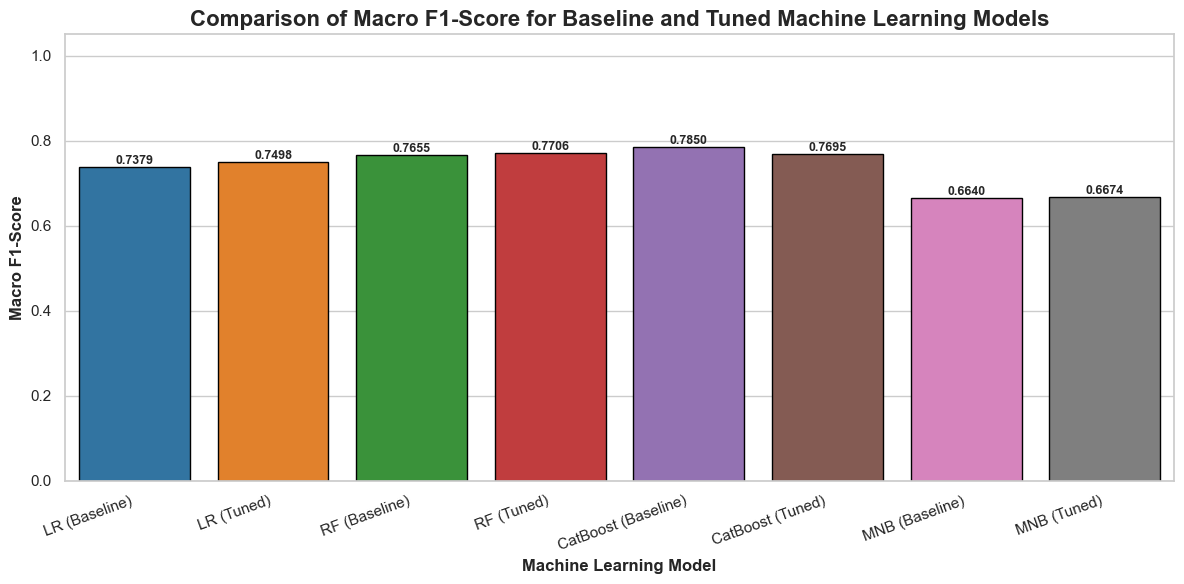

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
macro_f1_df = pd.DataFrame({
    "Model": [
        "LR (Baseline)",
        "LR (Tuned)",
        "RF (Baseline)",
        "RF (Tuned)",
        "CatBoost (Baseline)",
        "CatBoost (Tuned)",
        "MNB (Baseline)",
        "MNB (Tuned)"
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        tun_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        tun_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        tun_cat_macro_f1_score,
        bas_nb_macro_f1_score,
        tun_nb_macro_f1_score
    ]
})

# Plot settings
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=macro_f1_df,
    x="Model",
    y="Macro F1-Score",
    palette="tab10",
    edgecolor="black"
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Comparison of Macro F1-Score for Baseline and Tuned Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Macro F1-Score",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Best Performing Model 

In [41]:
import pandas as pd

# Create comparison DataFrame
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "CatBoost",
        "CatBoost",
        "Multinomial Naïve Bayes",
        "Multinomial Naïve Bayes"
    ],
    "Version": [
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned"
    ],
    "Accuracy": [
        bas_lr_accuracy,
        tun_lr_accuracy,
        bas_rf_accuracy,
        tun_rf_accuracy,
        bas_cb_accuracy,
        tun_cat_accuracy,
        bas_nb_accuracy,
        tun_nb_accuracy
    ],
    "Precision": [
        bas_lr_precision,
        tun_lr_precision,
        bas_rf_precision,
        tun_rf_precision,
        bas_cb_precision,
        tun_cat_precision,
        bas_nb_precision,
        tun_nb_precision
    ],
    "Recall": [
        bas_lr_recall,
        tun_lr_recall,
        bas_rf_recall,
        tun_rf_recall,
        bas_cb_recall,
        tun_cat_recall,
        bas_nb_recall,
        tun_nb_recall
    ],
    "F1-Score": [
        bas_lr_f1_score,
        tun_lr_f1_score,
        bas_rf_f1_score,
        tun_rf_f1_score,
        bas_cb_f1_score,
        tun_cat_f1_score,
        bas_nb_f1_score,
        tun_nb_f1_score
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        tun_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        tun_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        tun_cat_macro_f1_score,
        bas_nb_macro_f1_score,
        tun_nb_macro_f1_score
    ],
    "ROC-AUC": [
        bas_lr_roc_auc,
        tun_lr_roc_auc,
        bas_rf_roc_auc,
        tun_rf_roc_auc,
        bas_cb_roc_auc,
        tun_cat_roc_auc,
        bas_nb_roc_auc,
        tun_nb_roc_auc
    ]
})

# Calculate Overall Score
comparison_results["Overall Score"] = comparison_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Macro F1-Score",
        "ROC-AUC"
    ]
].mean(axis=1)

# Sort models
comparison_results = comparison_results.sort_values(
    by="Overall Score",
    ascending=False
).reset_index(drop=True)

# Display complete ranking

print("Overall Ranking of Machine Learning Models")

print(
    comparison_results[
        [
            "Model",
            "Version",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "Macro F1-Score",
            "ROC-AUC",
            "Overall Score"
        ]
    ].round(4)
)

# Best model
best_model = comparison_results.iloc[0]

print("Best Performing Model")

print(f"Model           : {best_model['Model']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")
print(f"Precision       : {best_model['Precision']:.4f}")
print(f"Recall          : {best_model['Recall']:.4f}")
print(f"F1-Score        : {best_model['F1-Score']:.4f}")
print(f"Macro F1-Score  : {best_model['Macro F1-Score']:.4f}")
print(f"ROC-AUC         : {best_model['ROC-AUC']:.4f}")
print(f"Overall Score   : {best_model['Overall Score']:.4f}")

Overall Ranking of Machine Learning Models
                     Model   Version  Accuracy  Precision  Recall  F1-Score  \
0                 CatBoost  Baseline    0.7817     0.7949  0.7817    0.7852   
1                 CatBoost     Tuned    0.7664     0.7814  0.7664    0.7696   
2            Random Forest     Tuned    0.7649     0.7819  0.7649    0.7707   
3            Random Forest  Baseline    0.7603     0.7755  0.7603    0.7657   
4      Logistic Regression     Tuned    0.7481     0.7526  0.7481    0.7500   
5      Logistic Regression  Baseline    0.7344     0.7455  0.7344    0.7380   
6  Multinomial Naïve Bayes     Tuned    0.6733     0.6765  0.6733    0.6676   
7  Multinomial Naïve Bayes  Baseline    0.6687     0.6659  0.6687    0.6643   

   Macro F1-Score  ROC-AUC  Overall Score  
0          0.7850   0.9324         0.8101  
1          0.7695   0.9263         0.7966  
2          0.7706   0.9234         0.7961  
3          0.7655   0.9189         0.7910  
4          0.7498   0.911

# Best Performing Model Based on Macro F1-Score 

In [43]:
import pandas as pd

# Create comparison DataFrame
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "CatBoost",
        "CatBoost",
        "Multinomial Naïve Bayes",
        "Multinomial Naïve Bayes"
    ],
    "Version": [
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned",
        "Baseline",
        "Tuned"
    ],
    "Macro F1-Score": [
        bas_lr_macro_f1_score,
        tun_lr_macro_f1_score,
        bas_rf_macro_f1_score,
        tun_rf_macro_f1_score,
        bas_cb_macro_f1_score,
        tun_cat_macro_f1_score,
        bas_nb_macro_f1_score,
        tun_nb_macro_f1_score
    ]
})

# Sort by Macro F1-Score
comparison_results = comparison_results.sort_values(
    by="Macro F1-Score",
    ascending=False
).reset_index(drop=True)

# Display ranking

print("Ranking of Machine Learning Models Based on Macro F1-Score")


print(comparison_results.round(4))

# Display best-performing model
best_model = comparison_results.iloc[0]


print("Best Performing Model")


print(f"Model           : {best_model['Model']}")
print(f"Macro F1-Score  : {best_model['Macro F1-Score']:.4f}")

Ranking of Machine Learning Models Based on Macro F1-Score
                     Model   Version  Macro F1-Score
0                 CatBoost  Baseline          0.7850
1            Random Forest     Tuned          0.7706
2                 CatBoost     Tuned          0.7695
3            Random Forest  Baseline          0.7655
4      Logistic Regression     Tuned          0.7498
5      Logistic Regression  Baseline          0.7379
6  Multinomial Naïve Bayes     Tuned          0.6674
7  Multinomial Naïve Bayes  Baseline          0.6640
Best Performing Model
Model           : CatBoost
Macro F1-Score  : 0.7850


# Save the Best Performing Model

In [46]:

import joblib

# I saved the best-performing CatBoost model.
joblib.dump(cb_pipeline, "Customer_Support_Best_Model.pkl")

# I displayed a confirmation message.
print("Best-performing CatBoost model was saved successfully as 'Customer_Support_Best_Model.pkl'.")

Best-performing CatBoost model was saved successfully as 'Customer_Support_Best_Model.pkl'.


# SHAP Analysis 

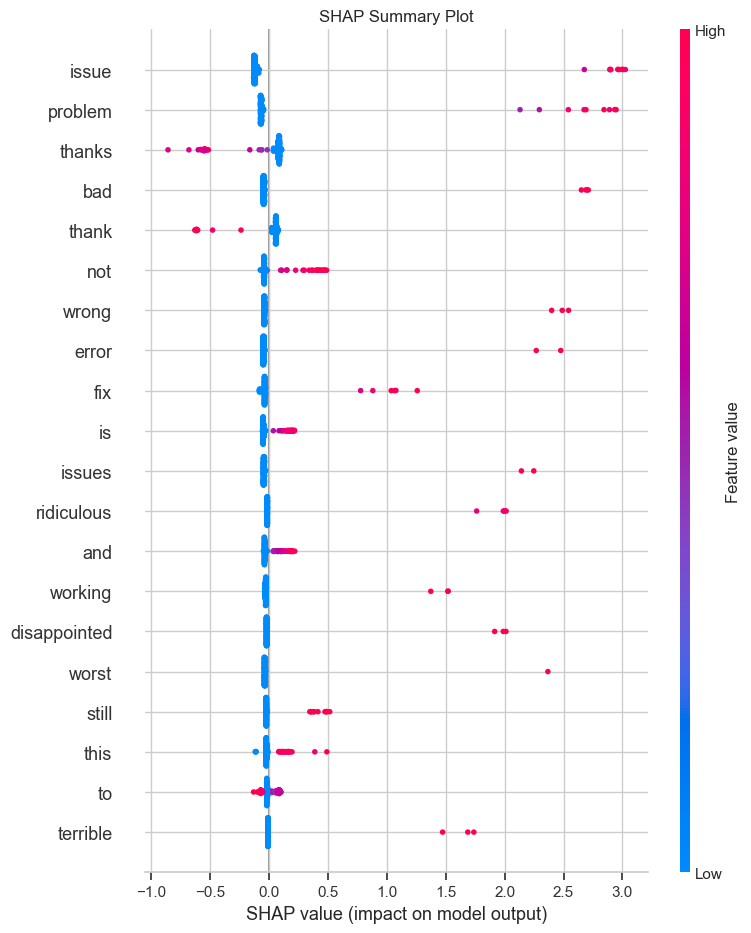

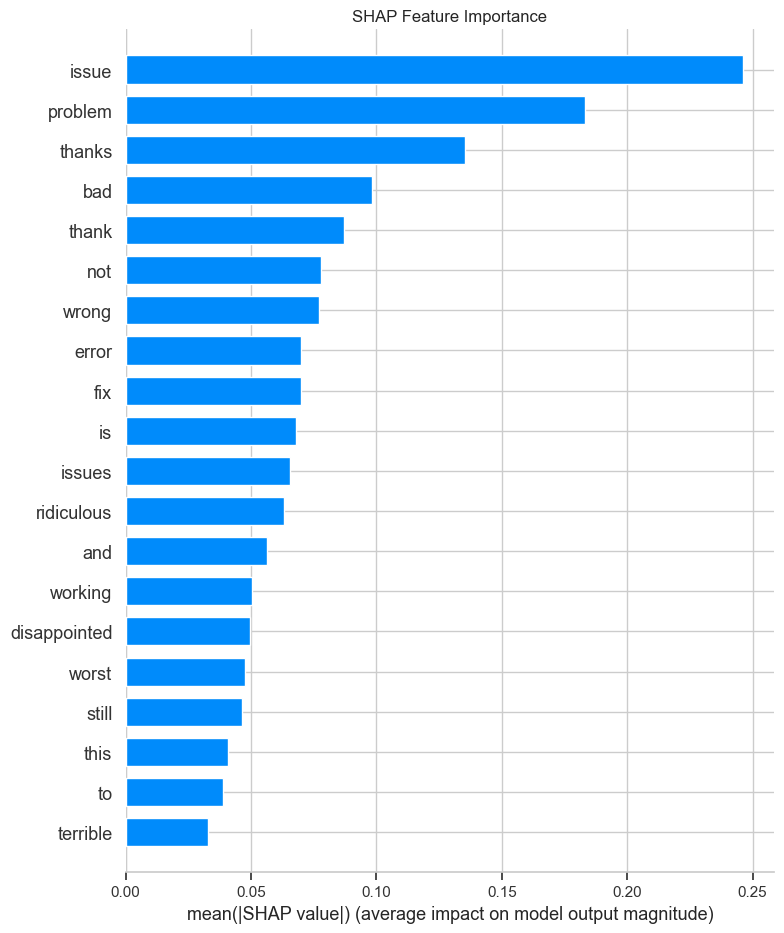

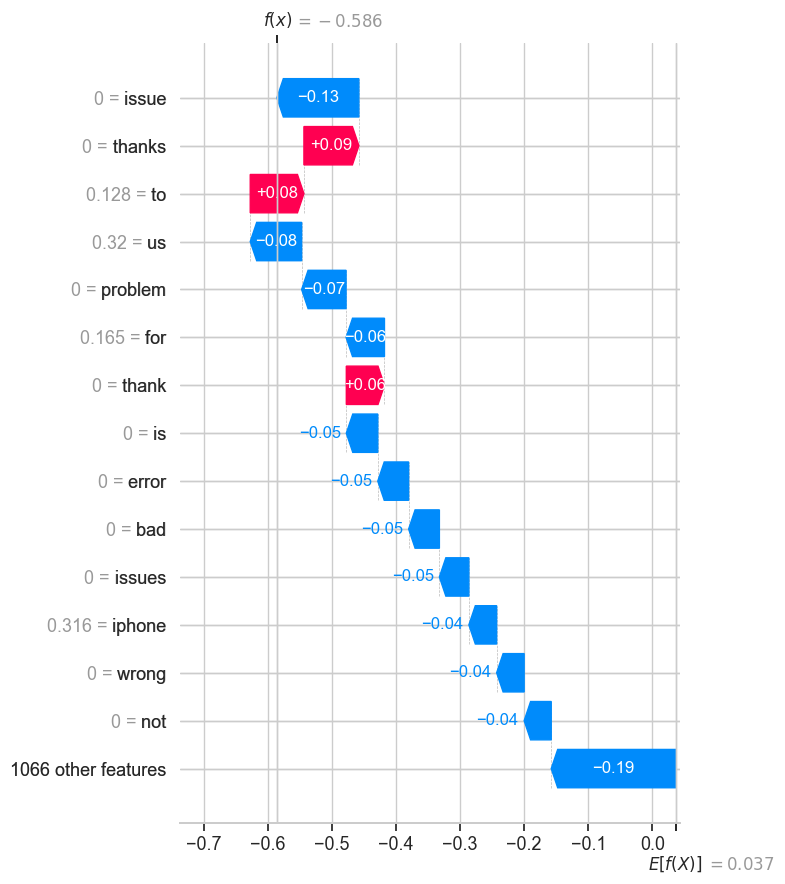

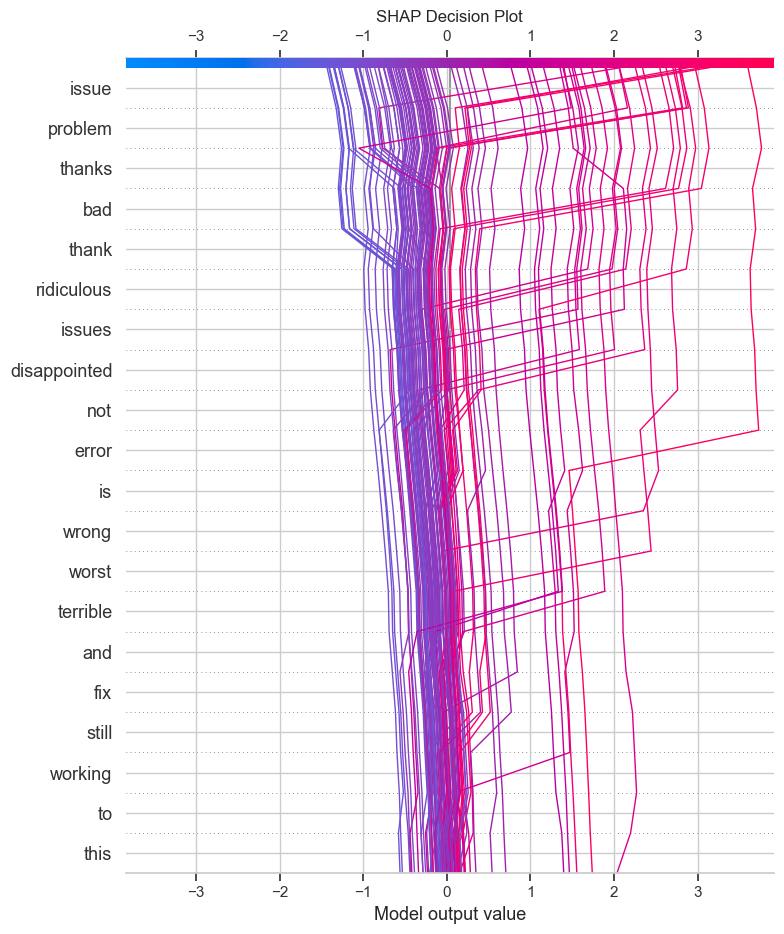

In [50]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Extract trained TF-IDF Vectorizer and CatBoost model
tfidf = cb_pipeline.named_steps["tfidf"]
cat_model = cb_pipeline.named_steps["clf"]

# Transform the test dataset
X_test_tfidf = tfidf.transform(X_test)

# Use only a subset for faster SHAP computation
sample_size = min(200, X_test_tfidf.shape[0])
X_sample = X_test_tfidf[:sample_size].toarray()

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Create SHAP explainer
explainer = shap.TreeExplainer(cat_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)


# Handle Multiclass SHAP Values


if isinstance(shap_values, list):

    class_id = 0

    shap_plot = shap_values[class_id]
    expected_value = explainer.expected_value[class_id]

else:

    shap_plot = shap_values
    expected_value = explainer.expected_value


# Plot 1 : SHAP Summary Plot


plt.figure(figsize=(12,7))

shap.summary_plot(
    shap_plot,
    X_sample,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()


# Plot 2 : SHAP Feature Importance


plt.figure(figsize=(12,7))

shap.summary_plot(
    shap_plot,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()


# Plot 3 : SHAP Waterfall Plot
sample_index = 0

explanation = shap.Explanation(
    values=shap_plot[sample_index],
    base_values=expected_value,
    data=X_sample[sample_index],
    feature_names=feature_names
)

plt.figure(figsize=(12,8))

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()


# Plot 4 : SHAP Decision Plot
plt.figure(figsize=(12,7))

shap.decision_plot(
    expected_value,
    shap_plot[:100],
    X_sample[:100],
    feature_names=feature_names,
    ignore_warnings=True,
    show=False
)

plt.title("SHAP Decision Plot")
plt.tight_layout()
plt.show()

# Human Evaluation Code : FeedBack Collection 

In [53]:
import tkinter as tk
from tkinter import ttk, messagebox
import joblib
import csv
import os
from datetime import datetime


MODEL_FILE = "Customer_Support_Best_Model.pkl"
EVALUATION_FILE = "Human_Evaluation.csv"

EXPECTED_CLASSES = [
    "Complaint",
    "Question",
    "Positive",
    "Other"
]


MODEL = None
MODEL_ERROR = None

try:
    MODEL = joblib.load(MODEL_FILE)

    if not hasattr(MODEL, "predict"):
        raise ValueError(
            "The loaded file does not contain a valid "
            "scikit-learn prediction model."
        )

except Exception as exc:
    MODEL_ERROR = str(exc)


class CustomerSupportDashboard(tk.Tk):

    def __init__(self):
        super().__init__()

        self.title(
            "Customer Support Tweet Classification & Human Evaluation"
        )

        self.geometry("1200x780")
        self.minsize(950, 650)
        self.configure(bg="#F4F6F8")

        self.last_tweet = ""
        self.last_prediction = ""

        self.setup_style()
        self.create_variables()
        self.create_header()
        self.create_notebook()
        self.create_prediction_tab()
        self.create_evaluation_tab()
        self.create_status_bar()

        self.bind(
            "<Control-Return>",
            lambda event: self.predict()
        )

        self.bind(
            "<Escape>",
            lambda event: self.clear_tweet()
        )

        self.protocol(
            "WM_DELETE_WINDOW",
            self.exit_application
        )

        if MODEL is None:
            self.status_var.set("Model loading error")
            self.after(300, self.show_model_error)
        else:
            self.status_var.set(
                "Model loaded successfully — Ready"
            )

    def setup_style(self):

        style = ttk.Style(self)

        try:
            style.theme_use("clam")
        except tk.TclError:
            pass

        style.configure(
            "TNotebook",
            background="#F4F6F8",
            borderwidth=0
        )

        style.configure(
            "TNotebook.Tab",
            font=("Segoe UI", 11, "bold"),
            padding=(22, 12)
        )

        style.configure(
            "TRadiobutton",
            font=("Segoe UI", 10),
            background="white"
        )

    def create_variables(self):

        self.prediction_var = tk.StringVar(
            value="Awaiting Prediction"
        )

        self.confidence_var = tk.StringVar(
            value="Confidence: —"
        )

        self.status_var = tk.StringVar(
            value="Loading model..."
        )

        self.human_rating_var = tk.StringVar(
            value="Correct"
        )

        self.ease_var = tk.IntVar(value=5)
        self.design_var = tk.IntVar(value=5)
        self.quality_var = tk.IntVar(value=5)

        self.probability_vars = {
            label: tk.StringVar(value="0.00%")
            for label in EXPECTED_CLASSES
        }

    def create_header(self):

        header = tk.Frame(
            self,
            bg="#17202A",
            height=105
        )

        header.pack(fill="x")
        header.pack_propagate(False)

        tk.Label(
            header,
            text="Customer Support Tweet Classification",
            bg="#17202A",
            fg="white",
            font=("Segoe UI", 22, "bold")
        ).pack(
            anchor="w",
            padx=30,
            pady=(18, 0)
        )

        tk.Label(
            header,
            text="Machine Learning Prediction & Human Evaluation Dashboard",
            bg="#17202A",
            fg="#BFC9D4",
            font=("Segoe UI", 10)
        ).pack(
            anchor="w",
            padx=32,
            pady=(3, 0)
        )

    def create_notebook(self):

        container = tk.Frame(
            self,
            bg="#F4F6F8"
        )

        container.pack(
            fill="both",
            expand=True,
            padx=22,
            pady=(18, 10)
        )

        self.notebook = ttk.Notebook(container)

        self.notebook.pack(
            fill="both",
            expand=True
        )

        self.prediction_frame = tk.Frame(
            self.notebook,
            bg="#F4F6F8"
        )

        self.evaluation_frame = tk.Frame(
            self.notebook,
            bg="#F4F6F8"
        )

        self.notebook.add(
            self.prediction_frame,
            text="  Tweet Classification  "
        )

        self.notebook.add(
            self.evaluation_frame,
            text="  Human Evaluation  "
        )

    def create_prediction_tab(self):

        frame = self.prediction_frame

        frame.grid_columnconfigure(
            0,
            weight=3
        )

        frame.grid_columnconfigure(
            1,
            weight=2
        )

        frame.grid_rowconfigure(
            0,
            weight=1
        )

        input_card = tk.Frame(
            frame,
            bg="white",
            highlightbackground="#D9DEE3",
            highlightthickness=1
        )

        input_card.grid(
            row=0,
            column=0,
            sticky="nsew",
            padx=(0, 10),
            pady=5
        )

        input_card.grid_rowconfigure(
            1,
            weight=1
        )

        input_card.grid_columnconfigure(
            0,
            weight=1
        )

        tk.Label(
            input_card,
            text="Tweet Input",
            bg="white",
            fg="#17202A",
            font=("Segoe UI", 15, "bold")
        ).grid(
            row=0,
            column=0,
            sticky="w",
            padx=22,
            pady=(20, 10)
        )

        text_frame = tk.Frame(
            input_card,
            bg="white"
        )

        text_frame.grid(
            row=1,
            column=0,
            sticky="nsew",
            padx=22
        )

        text_frame.grid_rowconfigure(
            0,
            weight=1
        )

        text_frame.grid_columnconfigure(
            0,
            weight=1
        )

        self.tweet_text = tk.Text(
            text_frame,
            wrap="word",
            font=("Segoe UI", 12),
            bg="#FAFBFC",
            fg="#17202A",
            insertbackground="#17202A",
            relief="flat",
            padx=15,
            pady=15,
            undo=True
        )

        self.tweet_text.grid(
            row=0,
            column=0,
            sticky="nsew"
        )

        scrollbar = ttk.Scrollbar(
            text_frame,
            orient="vertical",
            command=self.tweet_text.yview
        )

        scrollbar.grid(
            row=0,
            column=1,
            sticky="ns"
        )

        self.tweet_text.configure(
            yscrollcommand=scrollbar.set
        )

        button_frame = tk.Frame(
            input_card,
            bg="white"
        )

        button_frame.grid(
            row=2,
            column=0,
            sticky="ew",
            padx=22,
            pady=20
        )

        for column in range(4):
            button_frame.grid_columnconfigure(
                column,
                weight=1
            )

        tk.Button(
            button_frame,
            text="Predict",
            command=self.predict,
            bg="#1F6FEB",
            fg="white",
            activebackground="#1557B0",
            activeforeground="white",
            relief="flat",
            font=("Segoe UI", 10, "bold"),
            cursor="hand2",
            padx=12,
            pady=10
        ).grid(
            row=0,
            column=0,
            sticky="ew",
            padx=(0, 5)
        )

        tk.Button(
            button_frame,
            text="Clear",
            command=self.clear_tweet,
            bg="#E9ECEF",
            fg="#17202A",
            activebackground="#D6DADF",
            relief="flat",
            font=("Segoe UI", 10, "bold"),
            cursor="hand2",
            padx=12,
            pady=10
        ).grid(
            row=0,
            column=1,
            sticky="ew",
            padx=5
        )

        tk.Button(
            button_frame,
            text="Load Example",
            command=self.load_example,
            bg="#E9ECEF",
            fg="#17202A",
            activebackground="#D6DADF",
            relief="flat",
            font=("Segoe UI", 10, "bold"),
            cursor="hand2",
            padx=12,
            pady=10
        ).grid(
            row=0,
            column=2,
            sticky="ew",
            padx=5
        )

        tk.Button(
            button_frame,
            text="Exit",
            command=self.exit_application,
            bg="#C0392B",
            fg="white",
            activebackground="#922B21",
            activeforeground="white",
            relief="flat",
            font=("Segoe UI", 10, "bold"),
            cursor="hand2",
            padx=12,
            pady=10
        ).grid(
            row=0,
            column=3,
            sticky="ew",
            padx=(5, 0)
        )

        result_card = tk.Frame(
            frame,
            bg="white",
            highlightbackground="#D9DEE3",
            highlightthickness=1
        )

        result_card.grid(
            row=0,
            column=1,
            sticky="nsew",
            padx=(10, 0),
            pady=5
        )

        result_card.grid_columnconfigure(
            0,
            weight=1
        )

        tk.Label(
            result_card,
            text="Prediction Result",
            bg="white",
            fg="#17202A",
            font=("Segoe UI", 15, "bold")
        ).grid(
            row=0,
            column=0,
            sticky="w",
            padx=22,
            pady=(20, 12)
        )

        self.result_card = tk.Frame(
            result_card,
            bg="#F1F5F9",
            height=130
        )

        self.result_card.grid(
            row=1,
            column=0,
            sticky="ew",
            padx=22,
            pady=(0, 15)
        )

        self.result_card.grid_propagate(False)

        self.result_label = tk.Label(
            self.result_card,
            textvariable=self.prediction_var,
            bg="#F1F5F9",
            fg="#17202A",
            font=("Segoe UI", 20, "bold")
        )

        self.result_label.pack(
            expand=True,
            pady=(15, 0)
        )

        self.confidence_label = tk.Label(
            self.result_card,
            textvariable=self.confidence_var,
            bg="#F1F5F9",
            fg="#566573",
            font=("Segoe UI", 11)
        )

        self.confidence_label.pack(
            pady=(0, 15)
        )

        tk.Label(
            result_card,
            text="Prediction Probabilities",
            bg="white",
            fg="#17202A",
            font=("Segoe UI", 12, "bold")
        ).grid(
            row=2,
            column=0,
            sticky="w",
            padx=22,
            pady=(5, 12)
        )

        self.progress_bars = {}

        probability_colors = {
            "Complaint": "#E74C3C",
            "Question": "#3498DB",
            "Positive": "#27AE60",
            "Other": "#8E44AD"
        }

        for index, label in enumerate(EXPECTED_CLASSES):

            row = 3 + index * 2

            tk.Label(
                result_card,
                text=label,
                bg="white",
                fg="#34495E",
                font=("Segoe UI", 10, "bold")
            ).grid(
                row=row,
                column=0,
                sticky="w",
                padx=22,
                pady=(5, 0)
            )

            tk.Label(
                result_card,
                textvariable=self.probability_vars[label],
                bg="white",
                fg="#566573",
                font=("Segoe UI", 9)
            ).grid(
                row=row,
                column=0,
                sticky="e",
                padx=22,
                pady=(5, 0)
            )

            bar_frame = tk.Frame(
                result_card,
                bg="#E5E7EB",
                height=18
            )

            bar_frame.grid(
                row=row + 1,
                column=0,
                sticky="ew",
                padx=22,
                pady=(2, 5)
            )

            canvas = tk.Canvas(
                bar_frame,
                height=18,
                bg="#E5E7EB",
                highlightthickness=0
            )

            canvas.pack(
                fill="both",
                expand=True
            )

            self.progress_bars[label] = (
                canvas,
                probability_colors[label]
            )

        tk.Label(
            result_card,
            text="Tip: Press Ctrl + Enter to predict.",
            bg="white",
            fg="#7F8C8D",
            font=("Segoe UI", 9, "italic")
        ).grid(
            row=11,
            column=0,
            sticky="w",
            padx=22,
            pady=(20, 15)
        )

    def create_evaluation_tab(self):

        frame = self.evaluation_frame

        frame.grid_columnconfigure(
            0,
            weight=1
        )

        frame.grid_rowconfigure(
            1,
            weight=1
        )

        tk.Label(
            frame,
            text="Human Evaluation",
            bg="#F4F6F8",
            fg="#17202A",
            font=("Segoe UI", 18, "bold")
        ).grid(
            row=0,
            column=0,
            sticky="w",
            padx=10,
            pady=(5, 15)
        )

        card = tk.Frame(
            frame,
            bg="white",
            highlightbackground="#D9DEE3",
            highlightthickness=1
        )

        card.grid(
            row=1,
            column=0,
            sticky="nsew",
            padx=5,
            pady=5
        )

        card.grid_columnconfigure(
            1,
            weight=1
        )

        tk.Label(
            card,
            text="Tweet",
            bg="white",
            font=("Segoe UI", 10, "bold")
        ).grid(
            row=0,
            column=0,
            sticky="nw",
            padx=20,
            pady=(20, 8)
        )

        self.eval_tweet = tk.Text(
            card,
            height=4,
            wrap="word",
            font=("Segoe UI", 10),
            bg="#FAFBFC",
            relief="solid",
            borderwidth=1
        )

        self.eval_tweet.grid(
            row=0,
            column=1,
            sticky="ew",
            padx=(0, 20),
            pady=(20, 8)
        )

        tk.Label(
            card,
            text="Model Prediction",
            bg="white",
            font=("Segoe UI", 10, "bold")
        ).grid(
            row=1,
            column=0,
            sticky="w",
            padx=20,
            pady=8
        )

        self.eval_prediction_label = tk.Label(
            card,
            text="—",
            bg="#F1F5F9",
            fg="#17202A",
            font=("Segoe UI", 11, "bold"),
            anchor="w",
            padx=10,
            pady=8
        )

        self.eval_prediction_label.grid(
            row=1,
            column=1,
            sticky="ew",
            padx=(0, 20),
            pady=8
        )

        tk.Label(
            card,
            text="Human Rating",
            bg="white",
            font=("Segoe UI", 10, "bold")
        ).grid(
            row=2,
            column=0,
            sticky="w",
            padx=20,
            pady=8
        )

        rating_frame = tk.Frame(
            card,
            bg="white"
        )

        rating_frame.grid(
            row=2,
            column=1,
            sticky="w",
            padx=(0, 20),
            pady=8
        )

        ttk.Radiobutton(
            rating_frame,
            text="Correct",
            variable=self.human_rating_var,
            value="Correct"
        ).pack(
            side="left",
            padx=(0, 25)
        )

        ttk.Radiobutton(
            rating_frame,
            text="Incorrect",
            variable=self.human_rating_var,
            value="Incorrect"
        ).pack(
            side="left"
        )

        self.create_rating_row(
            card,
            3,
            "Ease of Use",
            self.ease_var
        )

        self.create_rating_row(
            card,
            4,
            "Interface Design",
            self.design_var
        )

        self.create_rating_row(
            card,
            5,
            "Prediction Quality",
            self.quality_var
        )

        tk.Label(
            card,
            text="Comments",
            bg="white",
            font=("Segoe UI", 10, "bold")
        ).grid(
            row=6,
            column=0,
            sticky="nw",
            padx=20,
            pady=(12, 8)
        )

        self.comments_text = tk.Text(
            card,
            height=6,
            wrap="word",
            font=("Segoe UI", 10),
            bg="#FAFBFC",
            relief="solid",
            borderwidth=1
        )

        self.comments_text.grid(
            row=6,
            column=1,
            sticky="ew",
            padx=(0, 20),
            pady=(12, 8)
        )

        tk.Button(
            card,
            text="Save Evaluation",
            command=self.save_evaluation,
            bg="#27AE60",
            fg="white",
            activebackground="#1E8449",
            activeforeground="white",
            relief="flat",
            font=("Segoe UI", 11, "bold"),
            cursor="hand2",
            padx=20,
            pady=10
        ).grid(
            row=7,
            column=1,
            sticky="e",
            padx=(0, 20),
            pady=15
        )

    def create_rating_row(
        self,
        parent,
        row,
        label,
        variable
    ):

        tk.Label(
            parent,
            text=label,
            bg="white",
            font=("Segoe UI", 10, "bold")
        ).grid(
            row=row,
            column=0,
            sticky="w",
            padx=20,
            pady=8
        )

        rating_frame = tk.Frame(
            parent,
            bg="white"
        )

        rating_frame.grid(
            row=row,
            column=1,
            sticky="w",
            padx=(0, 20),
            pady=8
        )

        for value in range(1, 6):

            ttk.Radiobutton(
                rating_frame,
                text=str(value),
                variable=variable,
                value=value
            ).pack(
                side="left",
                padx=(0, 15)
            )

    def create_status_bar(self):

        status = tk.Frame(
            self,
            bg="#17202A",
            height=32
        )

        status.pack(fill="x")
        status.pack_propagate(False)

        tk.Label(
            status,
            textvariable=self.status_var,
            bg="#17202A",
            fg="#D5DBDB",
            font=("Segoe UI", 9),
            anchor="w"
        ).pack(
            side="left",
            padx=15
        )

        tk.Label(
            status,
            text="Model: Customer_Support_Best_Model.pkl",
            bg="#17202A",
            fg="#AAB7B8",
            font=("Segoe UI", 9)
        ).pack(
            side="right",
            padx=15
        )

    def show_model_error(self):

        if MODEL_ERROR:

            messagebox.showerror(
                "Model Loading Error",
                "Customer_Support_Best_Model.pkl could not be loaded.\n\n"
                f"Error:\n{MODEL_ERROR}\n\n"
                "Make sure the model file was saved with joblib "
                "and is in the same folder as this Python file."
            )

    def predict(self):

        user_text = (
            self.tweet_text
            .get("1.0", "end-1c")
            .strip()
        )

        if not user_text:

            messagebox.showwarning(
                "Input Required",
                "Please enter a tweet before clicking Predict."
            )

            return

        if MODEL is None:

            messagebox.showerror(
                "Model Error",
                f"The model could not be loaded.\n\n{MODEL_ERROR}"
            )

            return

        try:

            prediction = MODEL.predict(
                [user_text]
            )[0]

            probabilities_raw = MODEL.predict_proba(
                [user_text]
            )[0]

            classes = MODEL.classes_

            probabilities = {}

            for class_name, probability in zip(
                classes,
                probabilities_raw
            ):

                probabilities[str(class_name)] = float(
                    probability
                )

            prediction_label = str(
                prediction
            )

            confidence = probabilities.get(
                prediction_label,
                max(probabilities.values())
            )

            self.last_tweet = user_text
            self.last_prediction = prediction_label

            self.prediction_var.set(
                prediction_label
            )

            self.confidence_var.set(
                f"Confidence: {confidence * 100:.2f}%"
            )

            for label in EXPECTED_CLASSES:

                value = probabilities.get(
                    label,
                    0.0
                )

                self.probability_vars[
                    label
                ].set(
                    f"{value * 100:.2f}%"
                )

                self.update_probability_bar(
                    label,
                    value
                )

            self.update_result_card(
                prediction_label
            )

            self.eval_tweet.delete(
                "1.0",
                "end"
            )

            self.eval_tweet.insert(
                "1.0",
                user_text
            )

            self.eval_prediction_label.config(
                text=prediction_label
            )

            self.status_var.set(
                f"Prediction completed: {prediction_label}"
            )

        except Exception as exc:

            messagebox.showerror(
                "Prediction Error",
                f"{exc}"
            )

            self.status_var.set(
                "Prediction failed"
            )

    def update_probability_bar(
        self,
        label,
        value
    ):

        canvas, bar_color = self.progress_bars[label]

        canvas.delete("all")

        width = canvas.winfo_width()

        if width <= 1:
            width = 300

        bar_width = int(
            width * max(
                0,
                min(value, 1)
            )
        )

        canvas.create_rectangle(
            0,
            0,
            bar_width,
            18,
            fill=bar_color,
            outline=""
        )

    def update_result_card(
        self,
        prediction
    ):

        card_colors = {

            "Complaint": (
                "#FDEDEC",
                "#C0392B"
            ),

            "Question": (
                "#EBF5FB",
                "#2874A6"
            ),

            "Positive": (
                "#EAFAF1",
                "#239B56"
            ),

            "Other": (
                "#F5EEF8",
                "#7D3C98"
            )
        }

        background, foreground = card_colors.get(
            prediction,
            (
                "#F1F5F9",
                "#17202A"
            )
        )

        self.result_card.config(
            bg=background
        )

        self.result_label.config(
            bg=background,
            fg=foreground
        )

        self.confidence_label.config(
            bg=background,
            fg=foreground
        )

    def clear_tweet(self):

        self.tweet_text.delete(
            "1.0",
            "end"
        )

        self.prediction_var.set(
            "Awaiting Prediction"
        )

        self.confidence_var.set(
            "Confidence: —"
        )

        for label in EXPECTED_CLASSES:

            self.probability_vars[
                label
            ].set(
                "0.00%"
            )

            canvas, _ = self.progress_bars[label]

            canvas.delete("all")

        self.result_card.config(
            bg="#F1F5F9"
        )

        self.result_label.config(
            bg="#F1F5F9",
            fg="#17202A"
        )

        self.confidence_label.config(
            bg="#F1F5F9",
            fg="#566573"
        )

        self.last_tweet = ""
        self.last_prediction = ""

        self.status_var.set(
            "Input cleared"
        )

    def load_example(self):

        example = (
            "I am really happy with the support team. "
            "They solved my problem quickly and professionally!"
        )

        self.tweet_text.delete(
            "1.0",
            "end"
        )

        self.tweet_text.insert(
            "1.0",
            example
        )

        self.status_var.set(
            "Example tweet loaded"
        )

    def save_evaluation(self):

        tweet = (
            self.eval_tweet
            .get("1.0", "end-1c")
            .strip()
        )

        model_prediction = (
            self.eval_prediction_label
            .cget("text")
        )

        human_rating = (
            self.human_rating_var
            .get()
        )

        ease_of_use = (
            self.ease_var
            .get()
        )

        interface_design = (
            self.design_var
            .get()
        )

        prediction_quality = (
            self.quality_var
            .get()
        )

        comments = (
            self.comments_text
            .get("1.0", "end-1c")
            .strip()
        )

        if not tweet:

            messagebox.showwarning(
                "Missing Tweet",
                "Please enter or predict a tweet "
                "before saving the evaluation."
            )

            return

        if model_prediction == "—":

            messagebox.showwarning(
                "Missing Prediction",
                "Please run the model prediction "
                "before saving the evaluation."
            )

            return

        file_exists = os.path.exists(
            EVALUATION_FILE
        )

        headers = [
            "Timestamp",
            "Tweet",
            "Model Prediction",
            "Human Rating",
            "Ease of Use",
            "Interface Design",
            "Prediction Quality",
            "Comments"
        ]

        row = [
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            ),
            tweet,
            model_prediction,
            human_rating,
            ease_of_use,
            interface_design,
            prediction_quality,
            comments
        ]

        try:

            with open(
                EVALUATION_FILE,
                "a",
                newline="",
                encoding="utf-8-sig"
            ) as csv_file:

                writer = csv.writer(
                    csv_file
                )

                if not file_exists:
                    writer.writerow(
                        headers
                    )

                writer.writerow(
                    row
                )

            messagebox.showinfo(
                "Evaluation Saved",
                "Human evaluation saved successfully.\n\n"
                f"File: {EVALUATION_FILE}"
            )

            self.comments_text.delete(
                "1.0",
                "end"
            )

            self.status_var.set(
                f"Evaluation saved to {EVALUATION_FILE}"
            )

        except Exception as exc:

            messagebox.showerror(
                "Save Error",
                f"Could not save the evaluation:\n\n{exc}"
            )

    def exit_application(self):

        answer = messagebox.askyesno(
            "Exit Application",
            "Are you sure you want to exit?"
        )

        if answer:
            self.destroy()


if __name__ == "__main__":

    app = CustomerSupportDashboard()

    app.mainloop()